# 🧠 딥러닝 과제 - 이미지 분류 & 시퀀스 모델

이번 과제는 두 가지 큰 주제로 구성됩니다.

| 파트 | 주제 | 프레임워크 |
|:---:|:---|:---:|
| PART 1 | 이진 분류 — Cats vs Dogs | PyTorch |
| PART 2 | 다중 분류 — CIFAR-10 (전이학습) | PyTorch |
| PART 3 | LSTM 텍스트 감성 분석 (IMDB) | Keras |
| PART 4 | LSTM 시계열 기온 예측 (예나 기후) | Keras |
| PART 5 | Character-Level Seq2Seq | Keras |

> 💡 **파일 안내** - 드라이브에 옮겨두지 않았다면 미리 옮겨두시길!
> - `jena_climate_2009_2016.csv` : PART 4 기온 예측에 사용
> - `words.txt` : PART 5 Seq2Seq에 사용

---

# ⚙️ PART 0. 공통 환경 설정

## 0-1. 라이브러리 설치 및 임포트

이 노트북은 **PyTorch** (이미지 파트)와 **Keras/TensorFlow** (시퀀스 파트)를 함께 사용합니다.

> Colab에서는 두 프레임워크가 모두 설치되어 있어 별도 설치 없이 바로 `import`할 수 있습니다.

In [1]:
!pip install albumentations datasets -q

# ── PyTorch 관련 ──────────────────────────────────────────────
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms, models, datasets
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
import random

# ── Keras / TensorFlow 관련 ───────────────────────────────────
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import pandas as pd

# ── 재현성을 위한 시드 고정 ────────────────────────────────────
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

# ── 사용 디바이스 확인 ──────────────────────────────────────────
# GPU가 있으면 'cuda', 없으면 'cpu' 로 자동 설정됩니다
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("PyTorch 사용 장치:", device)
print("TensorFlow GPU:", tf.config.list_physical_devices('GPU'))

PyTorch 사용 장치: cuda
TensorFlow GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 0-2. 한글 폰트 설정 (Colab)

Colab 기본 환경에는 한글 폰트가 없어서 그래프 제목 등에 한글이 깨집니다.
아래 셀에서 나눔고딕 폰트를 설치하고 matplotlib 기본 폰트로 설정합니다.

In [2]:
!apt-get -qq install fonts-nanum   # 나눔고딕 폰트 설치

import matplotlib.font_manager as fm
fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False   # 마이너스(-) 기호 깨짐 방지
print("폰트 설정 완료!")

Selecting previously unselected package fonts-nanum.
(Reading database ... 122402 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...
폰트 설정 완료!


---

# 📸 PART 1. 이진 분류 — Cats 🐱 vs Dogs 🐶

Microsoft의 **Cats vs Dogs** 데이터셋(~25,000장)으로 이진 분류 CNN을 처음부터 직접 구현합니다.

## 🔑 핵심 개념

### CNN (합성곱 신경망)이란?

이미지를 그냥 1차원으로 펼쳐서 FC에 넣으면 **위치 정보**가 사라집니다.
CNN은 작은 **필터(커널)** 를 이미지 위에 슬라이딩하면서 지역 패턴을 감지합니다.

```
Conv 레이어  : 필터가 이미지를 훑으며 엣지, 텍스처 등의 특징을 추출
BatchNorm   : 레이어 출력값을 정규화해 학습 안정화 (gradient vanishing 예방)
ReLU        : 음수를 0으로 만드는 활성화 함수 (비선형성 추가)
MaxPooling  : 특징 맵 크기를 절반으로 줄여 계산량 감소 + 위치 불변성 확보
```

### 이진 분류와 다중 분류의 차이

| 항목 | 이진 분류 (이번 파트) | 다중 분류 (PART 2) |
|:---:|:---:|:---:|
| 출력 노드 수 | **1개** | 클래스 수 |
| 활성화 함수 | **Sigmoid** → 0~1 확률 | Softmax → 합이 1 |
| 손실 함수 | **BCELoss** | CrossEntropyLoss |
| 예측 기준 | 출력 ≥ 0.5 → 양성(Dog) | argmax |

> 💡 `BCEWithLogitsLoss` = Sigmoid + BCELoss를 수치 안정성 있게 합친 것
> 이 경우 모델 마지막에 Sigmoid를 **붙이지 않아도** 됩니다!

### 데이터 증강 (Data Augmentation)

같은 이미지를 매 에폭마다 **다른 방식으로 변형**해서 학습합니다.
- 모델이 다양한 패턴을 보게 되어 **과적합이 줄어들고** 일반화 성능이 높아집니다.
- 예: 고양이를 뒤집거나 회전해도 여전히 고양이여야 합니다.

---

## 1-1. 데이터 로드

In [3]:
from datasets import load_dataset
from collections import Counter

print("📥 데이터셋 로딩 중... (처음 실행 시 다운로드로 시간이 걸립니다)")
dataset = load_dataset("microsoft/cats_vs_dogs")
print("완료:", dataset)

# ── Train / Val / Test 분할 ────────────────────────────────────
# 전체의 20%를 test로, 나머지 80%의 20%를 val로 사용합니다
train_test = dataset['train'].train_test_split(test_size=0.2, seed=42)
train_val  = train_test['train'].train_test_split(test_size=0.2, seed=42)
train_hf   = train_val['train']
val_hf     = train_val['test']
test_hf    = train_test['test']
print(f"Train: {len(train_hf)}장  |  Val: {len(val_hf)}장  |  Test: {len(test_hf)}장")

📥 데이터셋 로딩 중... (처음 실행 시 다운로드로 시간이 걸립니다)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00002.parquet:   0%|          | 0.00/330M [00:00<?, ?B/s]

data/train-00001-of-00002.parquet:   0%|          | 0.00/391M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/23410 [00:00<?, ? examples/s]

완료: DatasetDict({
    train: Dataset({
        features: ['image', 'labels'],
        num_rows: 23410
    })
})
Train: 14982장  |  Val: 3746장  |  Test: 4682장


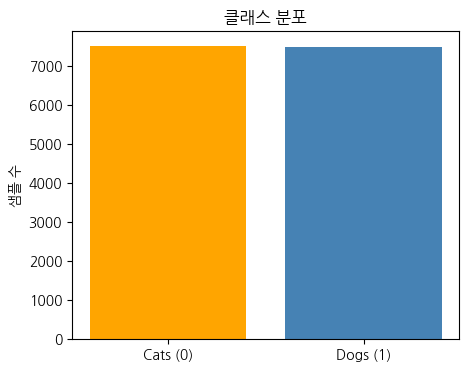

Cats: 7500장  |  Dogs: 7482장


/tmp/ipykernel_2696/2093336317.py:23: UserWarning: Glyph 128049 (\N{CAT FACE}) missing from font(s) NanumGothic.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_2696/2093336317.py:23: UserWarning: Glyph 128054 (\N{DOG FACE}) missing from font(s) NanumGothic.
  plt.tight_layout(); plt.show()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128049 (\N{CAT FACE}) missing from font(s) NanumGothic.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128054 (\N{DOG FACE}) missing from font(s) NanumGothic.
  fig.canvas.print_figure(bytes_io, **kw)


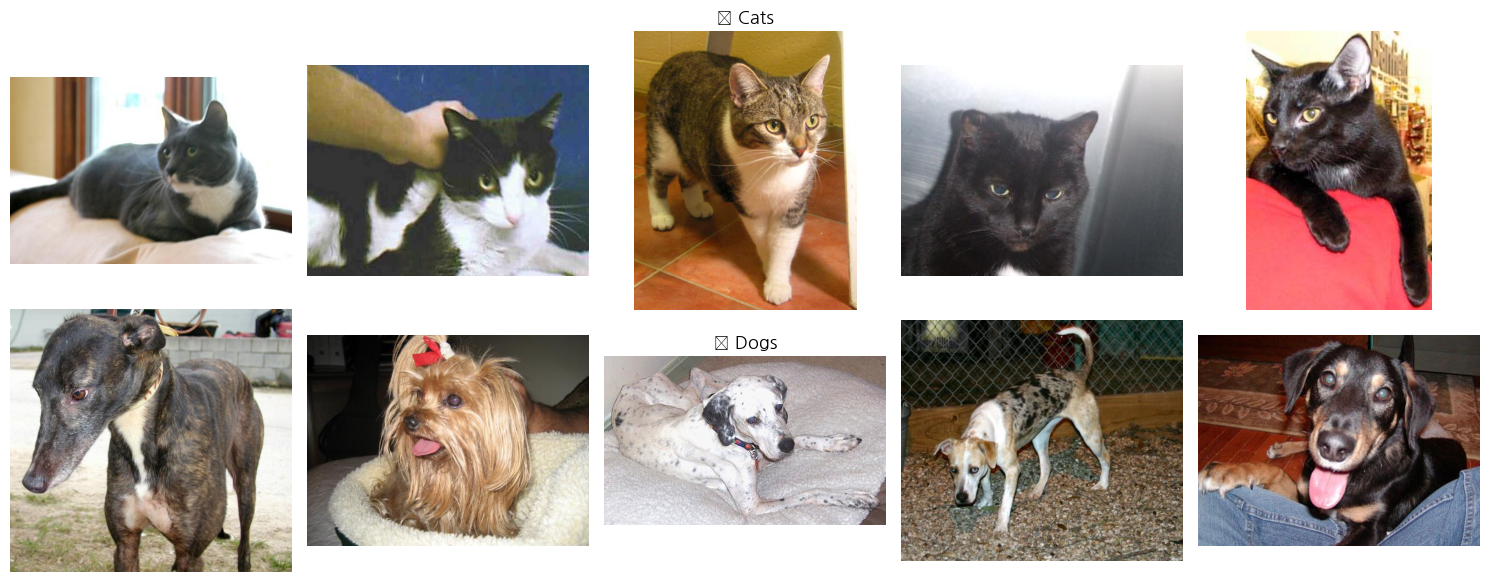

In [4]:
# ── 클래스 분포 확인 ────────────────────────────────────────────
# 두 클래스의 샘플 수가 비슷한지 확인합니다 (불균형이 심하면 정확도만으로 평가 금물!)
labels = [item['labels'] for item in train_hf]
cnt    = Counter(labels)
plt.figure(figsize=(5, 4))
plt.bar(['Cats (0)', 'Dogs (1)'], [cnt[0], cnt[1]], color=['orange', 'steelblue'])
plt.title('클래스 분포'); plt.ylabel('샘플 수'); plt.show()
print(f"Cats: {cnt[0]}장  |  Dogs: {cnt[1]}장")

# ── 샘플 이미지 시각화 ──────────────────────────────────────────
cats, dogs = [], []
for item in train_hf:
    if item['labels'] == 0 and len(cats) < 5: cats.append(item['image'])
    elif item['labels'] == 1 and len(dogs) < 5: dogs.append(item['image'])
    if len(cats) >= 5 and len(dogs) >= 5: break

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for i in range(5):
    axes[0, i].imshow(cats[i]); axes[0, i].axis('off')
    axes[1, i].imshow(dogs[i]); axes[1, i].axis('off')
axes[0, 2].set_title('🐱 Cats', fontsize=13)
axes[1, 2].set_title('🐶 Dogs', fontsize=13)
plt.tight_layout(); plt.show()

## 1-2. 데이터 전처리 및 증강

### albumentations vs torchvision transforms

| | albumentations | torchvision transforms |
|:---:|:---:|:---:|
| 속도 | 빠름 | 보통 |
| 기능 | 매우 다양 | 기본적인 것만 |
| 입력 | numpy array | PIL Image |

---
#### 아래에서 적용하는 증강 기법들:
1. 기본 전처리

- A.Resize(h, w): 이미지 전체 크기를 h x w 크기로 변환
- A.CenterCrop(h, w): 이미지 중앙을 기준으로 h x w만큼 잘라냄

2. 데이터 증강 (Data Augmentation)

- A.HorizontalFlip(p): p의 확률로 이미지를 좌우 반전 (고양이/개는 방향이 바뀌어도 같은 동물)
- A.Rotate(limit, p): limit(-x ~ +x)의 각도 내에서, p의 확률로 이미지 랜덤 회전

3. 색상 변환

- A.ColorJitter(brightness, contrast, saturation, hue, p): 밝기(brightness), 대비(contrast), 채도(saturation), 색조(hue)를 p의 확률로 랜덤 변환
- A.ToGray(p): p의 확률로 이미지를 흑백으로 변환

4. 정규화 (Normalization)

- A.Normalize(mean, std): ImageNet 평균/표준편차로 정규화 → 전이학습 시 필수!


In [5]:
import albumentations as A
from albumentations.pytorch import ToTensorV2

# 공통 mean, std 값
mean = [0.485, 0.456, 0.406]
std  = [0.229, 0.224, 0.225]

# ── 학습용 transform : 증강 O ────────────────────────────────
train_transform = A.Compose([
    A.Resize(256, 256),                                       # 256×256으로 변환
    A.HorizontalFlip(p=0.5),                                  # 50% 확률로 좌우 반전
    A.Rotate(limit=30, p=0.5),                                # ±30도 이내 회전
    A.ColorJitter(brightness=0.2, contrast=0.2,
                  saturation=0.2, hue=0.1, p=0.5),           # 50% 확률로 색상 변환
    A.Normalize(mean=mean, std=std),                           # 픽셀값 정규화
    ToTensorV2()                                              # numpy → PyTorch Tensor
])

# ── 검증/테스트용 transform : 증강 X (크기 조정 + 정규화만) ─────
val_test_transform = A.Compose([
    A.Resize(256, 256),
    A.Normalize(mean=mean, std=std),
    ToTensorV2()
])
print("Transform 정의 완료!")

Transform 정의 완료!


In [6]:
import torch
from torch.utils.data import Dataset, DataLoader
import numpy as np

class CatsDogsDataset(Dataset):
    def __init__(self, hf_dataset, transform=None):
        self.dataset   = hf_dataset
        self.transform = transform

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        item  = self.dataset[idx]
        image = item['image']
        label = item['labels']

        # PIL Image → numpy array (RGB 보장)
        try:
            image = np.array(image.convert('RGB'))
        except Exception as e:
            print(f"이미지 로딩 오류 (idx={idx}): {e}")
            image = np.zeros((256, 256, 3), dtype=np.uint8)

        if self.transform:
            image = self.transform(image=image)['image']

        label = torch.tensor(label, dtype=torch.float32)
        return image, label

train_ds = CatsDogsDataset(train_hf, train_transform)
val_ds   = CatsDogsDataset(val_hf,   val_test_transform)
test_ds  = CatsDogsDataset(test_hf,  val_test_transform)

BATCH_SIZE = 32

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"Train batches: {len(train_loader)}")
print(f"Val   batches: {len(val_loader)}")
print(f"Test  batches: {len(test_loader)}")

Train batches: 469
Val   batches: 118
Test  batches: 147


In [11]:
import torch.nn as nn
import torch.nn.functional as F

class AlexNetBinary(nn.Module):
    def __init__(self):
        super(AlexNetBinary, self).__init__()

        # ── 특징 추출기 (Feature Extractor) ─────────────────────
        # AlexNet 구조: Conv → ReLU → MaxPool 반복
        self.features = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=11, stride=4, padding=2),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),
            nn.Conv2d(64, 192, kernel_size=5, padding=2),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),
            nn.Conv2d(192, 384, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(384, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),
        )

        # 256×256 입력 기준으로 features 출력 크기 자동 계산
        # Conv 레이어를 통과한 뒤 정확한 크기를 모르니까 실제로 한 번 통과시켜서 크기를 재는 것
        dummy = torch.randn(1, 3, 256, 256)
        output_size = self.features(dummy).view(1, -1).size(1)

        # ── 분류기 (Classifier) ──────────────────────────────────
        self.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(output_size, 4096),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(4096, 4096),
            nn.ReLU(inplace=True),
            nn.Linear(4096, 1),             # 이진 분류 → 출력 1개
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)          # Flatten
        x = self.classifier(x)
        return x

model_catdog = AlexNetBinary()
total_params = sum(p.numel() for p in model_catdog.parameters())
print(f"전체 파라미터 수: {total_params:,}")

전체 파라미터 수: 70,639,425


In [12]:
from tqdm.auto import tqdm

def train_one_epoch(model, train_loader, criterion, optimizer, device):
    model.train()                                        # 학습 모드
    running_loss = 0.0
    correct = 0
    total   = 0

    pbar = tqdm(train_loader, desc='Training', leave=False)

    for images, labels in pbar:
        images = images.to(device)
        labels = labels.to(device).unsqueeze(1)          # (batch, 1) 형태로 맞춤

        outputs = model(images)
        loss    = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        predicted = (torch.sigmoid(outputs) > 0.5).float()
        total   += labels.size(0)
        correct += (predicted == labels).sum().item()

        pbar.set_postfix({'loss': f'{running_loss/total:.4f}',
                          'acc':  f'{correct/total:.4f}'})

    return running_loss / total, correct / total


def validate(model, val_loader, criterion, device):
    model.eval()                                         # 평가 모드
    running_loss = 0.0
    correct = 0
    total   = 0

    pbar = tqdm(val_loader, desc='Validation', leave=False)

    with torch.no_grad():
        for images, labels in pbar:
            images = images.to(device)
            labels = labels.to(device).unsqueeze(1)

            outputs = model(images)
            loss    = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            predicted = (torch.sigmoid(outputs) > 0.5).float()
            total   += labels.size(0)
            correct += (predicted == labels).sum().item()

            pbar.set_postfix({'loss': f'{running_loss/total:.4f}',
                              'acc':  f'{correct/total:.4f}'})

    return running_loss / total, correct / total

print("train_one_epoch(), validate() 함수 정의 완료")

train_one_epoch(), validate() 함수 정의 완료


## 1-5. 모델 학습

**Early Stopping**: 검증 손실이 `patience`번 연속 개선되지 않으면 학습 중단 → 과적합 방지

### 이 마크다운을 꼭 읽어주세요
아래 이미지처럼 뜨지 않는다면!!! CPU를 사용하고 있는 것입니다!!!!! cpu쓰면 1시간 넘게 걸려요!!!!!
정상적으로 돌린다면 Epoch1이 2분 안에 돌아가야 합니다!\
꼭 확인하고 기다려주세요!!!

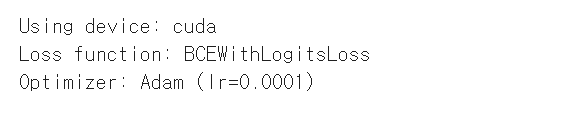

**참고: 아래 코드 전체 돌아가는 데에는 약 20분 정도 소요됩니다!**

In [13]:
device    = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

model_catdog = model_catdog.to(device)

criterion = nn.BCEWithLogitsLoss()                          # 이진 분류 손실
optimizer = torch.optim.Adam(model_catdog.parameters(), lr=0.0001)

print("Loss function: BCEWithLogitsLoss")
print("Optimizer: Adam (lr=0.0001)")

NUM_EPOCHS = 10
train_losses, train_accs = [], []
val_losses,   val_accs   = [], []

best_val_acc = 0.0 # Initialize best validation accuracy

print("\n학습 시작!\n")

for epoch in tqdm(range(NUM_EPOCHS), desc='Overall Progress'):
    train_loss, train_acc = train_one_epoch(model_catdog, train_loader, criterion, optimizer, device)
    val_loss,   val_acc   = validate(model_catdog, val_loader, criterion, device)

    train_losses.append(train_loss); train_accs.append(train_acc)
    val_losses.append(val_loss);     val_accs.append(val_acc)

    print(f"\nEpoch [{epoch+1}/{NUM_EPOCHS}]")
    print(f"  Train Loss: {train_loss:.4f}, Train Acc: {train_acc*100:.2f}%")
    print(f"  Val   Loss: {val_loss:.4f},   Val   Acc: {val_acc*100:.2f}%")

    # Best 모델 저장 로직 추가
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model_catdog.state_dict(), 'catdog_best.pt')
        print(f"  ⭐ Best 모델 저장! (Val Acc: {best_val_acc*100:.2f}%)")


print("\n학습 완료!")
print(f"Best Train Acc: {max(train_accs)*100:.2f}%  (Epoch {train_accs.index(max(train_accs))+1})")
print(f"Best Val   Acc: {max(val_accs)*100:.2f}%  (Epoch {val_accs.index(max(val_accs))+1})")

Using device: cuda
Loss function: BCEWithLogitsLoss
Optimizer: Adam (lr=0.0001)

학습 시작!



Overall Progress:   0%|          | 0/10 [00:00<?, ?it/s]

Training:   0%|          | 0/469 [00:00<?, ?it/s]

Validation:   0%|          | 0/118 [00:00<?, ?it/s]


Epoch [1/10]
  Train Loss: 0.6448, Train Acc: 62.57%
  Val   Loss: 0.5761,   Val   Acc: 69.43%
  ⭐ Best 모델 저장! (Val Acc: 69.43%)


Training:   0%|          | 0/469 [00:00<?, ?it/s]

Validation:   0%|          | 0/118 [00:00<?, ?it/s]


Epoch [2/10]
  Train Loss: 0.5495, Train Acc: 72.19%
  Val   Loss: 0.5214,   Val   Acc: 72.77%
  ⭐ Best 모델 저장! (Val Acc: 72.77%)


Training:   0%|          | 0/469 [00:00<?, ?it/s]

KeyboardInterrupt: 

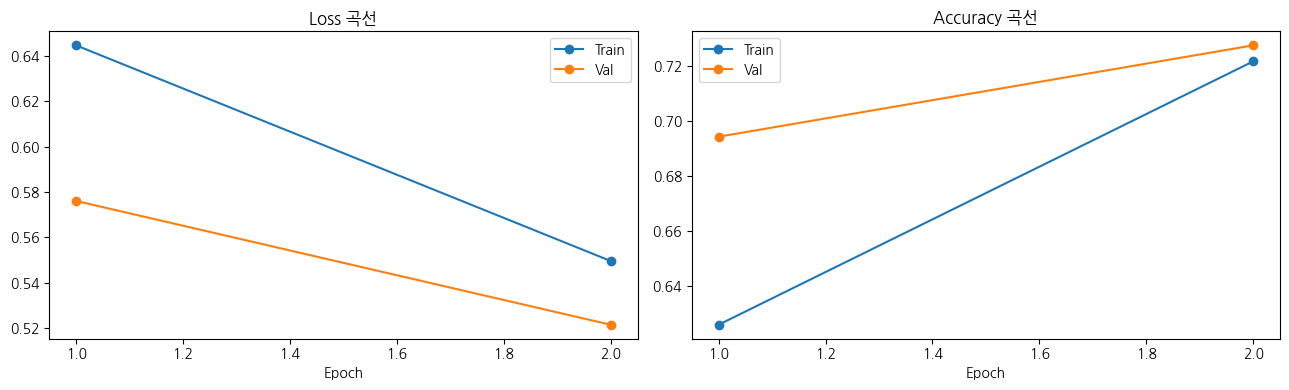

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
ep = range(1, len(train_losses)+1)

axes[0].plot(ep, train_losses, marker='o', label='Train')
axes[0].plot(ep, val_losses,   marker='o', label='Val')
axes[0].set_title('Loss 곡선'); axes[0].set_xlabel('Epoch'); axes[0].legend()

axes[1].plot(ep, train_accs, marker='o', label='Train')
axes[1].plot(ep, val_accs,   marker='o', label='Val')
axes[1].set_title('Accuracy 곡선'); axes[1].set_xlabel('Epoch'); axes[1].legend()

plt.tight_layout(); plt.show()

## 1-6. 테스트 평가 & 예측 시각화

Best 모델을 불러와서 테스트 셋으로 최종 성능을 측정합니다.

Validation:   0%|          | 0/147 [00:00<?, ?it/s]

Test Set 평가 결과
Test Loss: 0.4708
Test Accuracy: 0.7749


/tmp/ipykernel_2696/2821771178.py:29: UserWarning: Glyph 128049 (\N{CAT FACE}) missing from font(s) NanumGothic.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_2696/2821771178.py:29: UserWarning: Glyph 128054 (\N{DOG FACE}) missing from font(s) NanumGothic.
  plt.tight_layout(); plt.show()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128049 (\N{CAT FACE}) missing from font(s) NanumGothic.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128054 (\N{DOG FACE}) missing from font(s) NanumGothic.
  fig.canvas.print_figure(bytes_io, **kw)


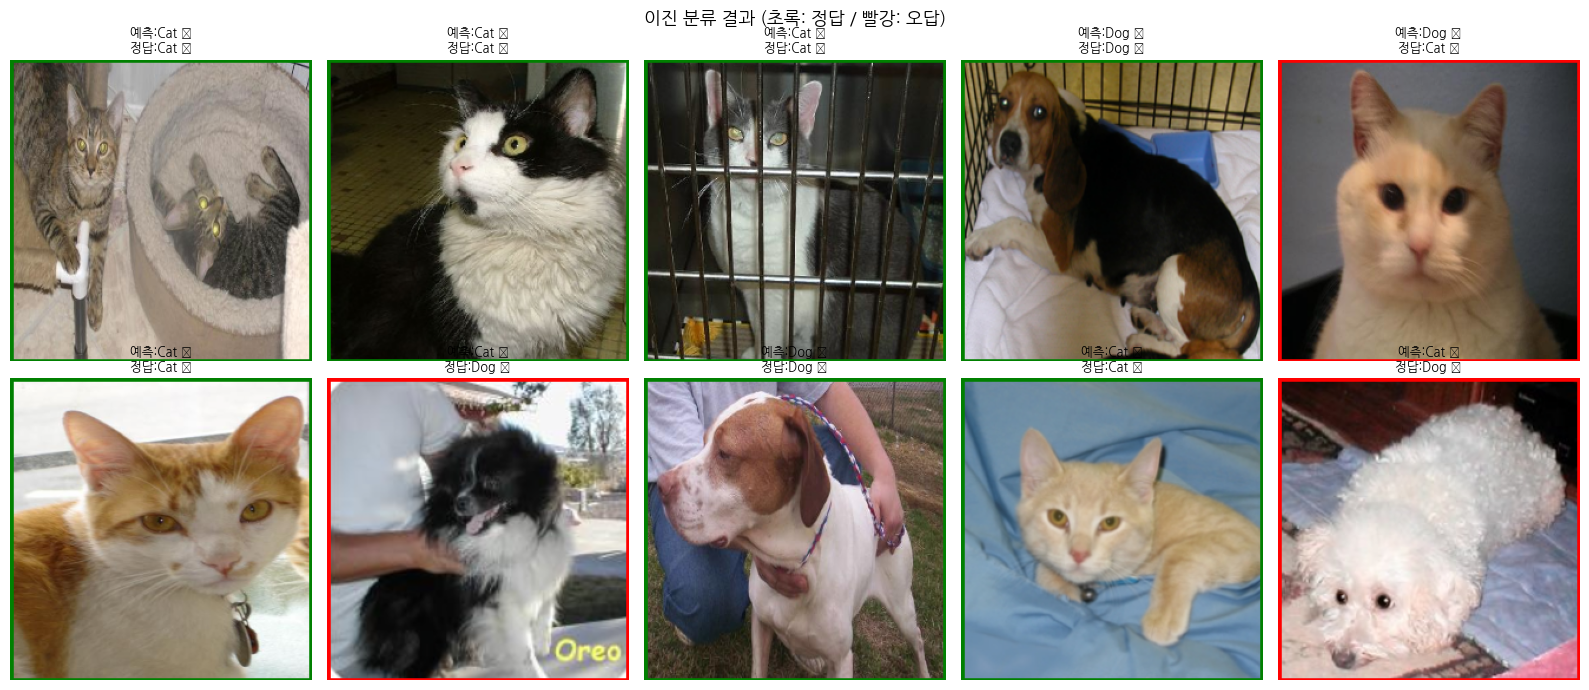

In [15]:
# ── 테스트 셋 평가 ──────────────────────────────────────────────
test_loss, test_acc = validate(model_catdog, test_loader, criterion, device)

print("Test Set 평가 결과")
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

# ── 10개 랜덤 예측 시각화 ────────────────────────────────────────
model_catdog.eval()
classes = ['Cat 🐱', 'Dog 🐶']
fig, axes = plt.subplots(2, 5, figsize=(16, 7))
axes = axes.ravel()

for i, idx in enumerate(random.sample(range(len(test_ds)), 10)):
    img_t, label = test_ds[idx]
    with torch.no_grad():
        out  = model_catdog(img_t.unsqueeze(0).to(device))
        pred = int((torch.sigmoid(out) > 0.5).item())

    img_np = img_t.permute(1,2,0).numpy()
    img_np = np.clip(img_np * [0.229,0.224,0.225] + [0.485,0.456,0.406], 0, 1)

    axes[i].imshow(img_np); axes[i].axis('off')
    axes[i].set_title(f"예측:{classes[pred]}\n정답:{classes[int(label)]}", fontsize=9)
    color = 'green' if pred == int(label) else 'red'
    axes[i].add_patch(patches.Rectangle((0,0), img_np.shape[1], img_np.shape[0],
                                         linewidth=4, edgecolor=color, facecolor='none'))
plt.suptitle('이진 분류 결과 (초록: 정답 / 빨강: 오답)', fontsize=13)
plt.tight_layout(); plt.show()

Validation:   0%|          | 0/147 [00:00<?, ?it/s]

🎯 테스트 Loss: 0.5314  |  테스트 Accuracy: 0.7202


/tmp/ipykernel_2696/3247320155.py:29: UserWarning: Glyph 128049 (\N{CAT FACE}) missing from font(s) NanumGothic.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_2696/3247320155.py:29: UserWarning: Glyph 128054 (\N{DOG FACE}) missing from font(s) NanumGothic.
  plt.tight_layout(); plt.show()


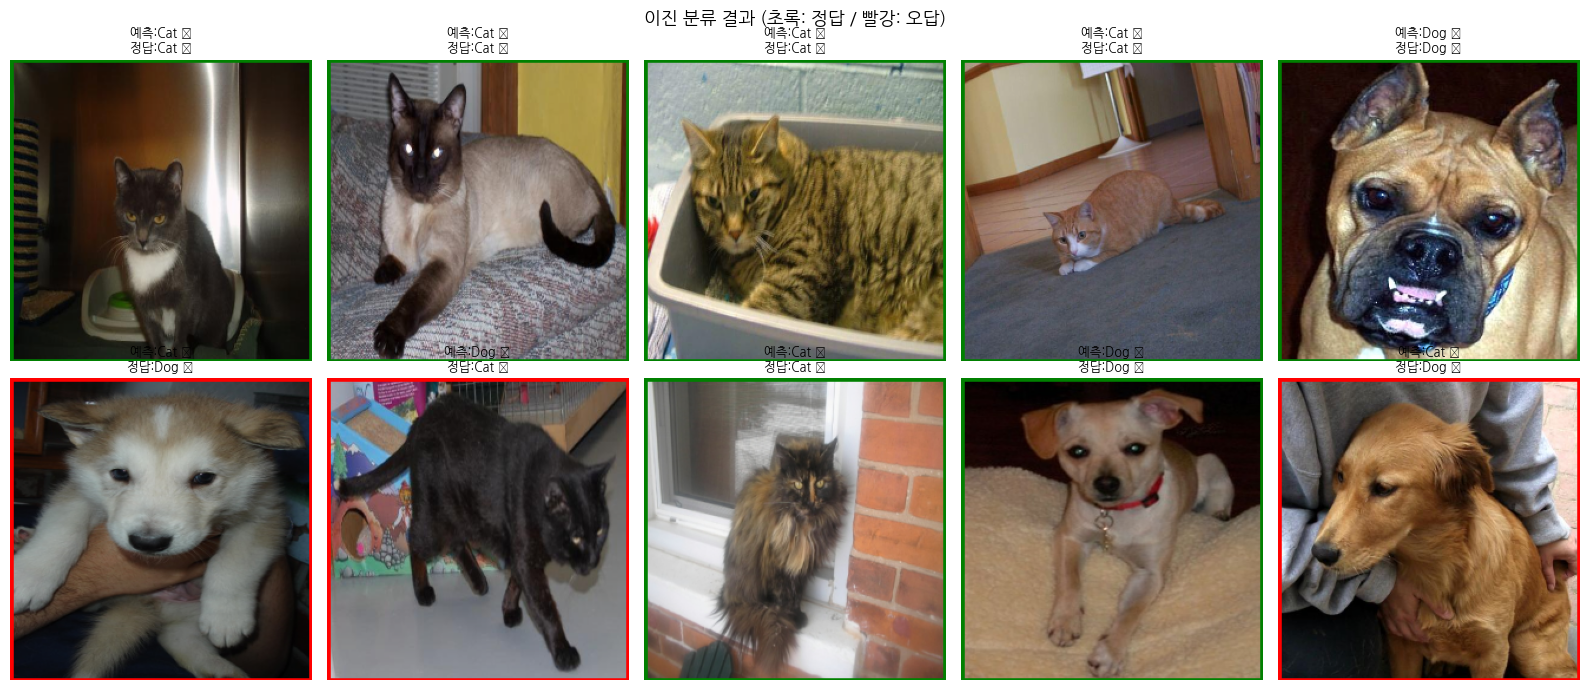

In [16]:
# ── Best 모델 불러오기 ──────────────────────────────────────────
model_catdog.load_state_dict(torch.load('catdog_best.pt', map_location=device))
test_loss, test_acc = validate(model_catdog, test_loader, criterion, device) # eval_epoch를 validate로 변경
print(f"🎯 테스트 Loss: {test_loss:.4f}  |  테스트 Accuracy: {test_acc:.4f}")

# ── 10개 랜덤 예측 시각화 ────────────────────────────────────────
model_catdog.eval()
classes = ['Cat 🐱', 'Dog 🐶']
fig, axes = plt.subplots(2, 5, figsize=(16, 7))
axes = axes.ravel()

for i, idx in enumerate(random.sample(range(len(test_ds)), 10)):
    img_t, label = test_ds[idx]
    with torch.no_grad():
        pred = int((torch.sigmoid(model_catdog(img_t.unsqueeze(0).to(device))) >= 0.5).item())

    # 역정규화 : 시각화를 위해 정규화 전 범위(0~1)로 복원
    img_np = img_t.permute(1,2,0).numpy()
    img_np = np.clip(img_np * [0.229,0.224,0.225] + [0.485,0.456,0.406], 0, 1)

    axes[i].imshow(img_np); axes[i].axis('off')
    axes[i].set_title(f"예측:{classes[pred]}\n정답:{classes[int(label)]}", fontsize=9)

    # 정답이면 초록, 틀리면 빨간 테두리
    color = 'green' if pred == int(label) else 'red'
    axes[i].add_patch(patches.Rectangle((0,0), img_np.shape[1], img_np.shape[0],
                                         linewidth=4, edgecolor=color, facecolor='none'))
plt.suptitle('이진 분류 결과 (초록: 정답 / 빨강: 오답)', fontsize=13)
plt.tight_layout(); plt.show()

---

# 🎨 PART 2. 다중 분류 — CIFAR-10 (전이학습)

**CIFAR-10** : 32×32 크기의 이미지 60,000장 (10개 클래스)

10개 클래스 : 비행기, 자동차, 새, 고양이, 사슴, 개, 개구리, 말, 배, 트럭

## 🔑 핵심 개념: 전이학습 (Transfer Learning)

전이학습이란, **누군가 이미 열심히 공부해놓은 노트를 빌려서** 우리 문제에 맞게 조금만 고쳐 쓰는 방법입니다.

여기서 빌려오는 것이 바로 **ResNet18** 이라는 모델입니다.
ResNet18은 **ImageNet** 이라는 대규모 데이터셋(약 140만 장, 1000개 클래스)으로 미리 학습된 모델로,
이미 수많은 이미지를 보며 **선, 곡선, 텍스처, 형태** 같은 특징을 잘 잡아내도록 훈련되어 있습니다.

> 💡 **ImageNet** : 사람, 자동차, 동물 등 1000가지 물체가 담긴 초대형 이미지 데이터셋입니다.
> 이 데이터로 학습된 모델은 이미지의 다양한 특징을 잘 추출할 수 있어서,
> **다른 이미지 문제에도 그대로 활용**할 수 있습니다.

### 왜 전이학습이 유리한가?
- ResNet18이 ImageNet에서 이미 학습한 **이미지 특징 추출 능력**을 그대로 가져옵니다!
- 이 능력은 CIFAR-10에서도 그대로 유효합니다!
- 마지막 분류기 부분만 CIFAR-10에 맞게 교체하면 **적은 데이터, 짧은 시간**으로 높은 성능을 낼 수 있습니다.

### 어느 레이어를 재학습할까?

```
ResNet18
  ├── layer1 ~ layer3  : 동결 (requires_grad=False) — ImageNet 특징 재사용
  ├── layer4            : 재학습 — 고수준 특징을 CIFAR-10에 맞게 미세조정
  └── fc (분류기)        : 교체 — (1000→10클래스)
```

> 앞쪽 레이어는 범용적인 저수준 특징(선, 곡선 등)을 학습하고,
> 뒤쪽 레이어일수록 데이터셋에 특화된 고수준 특징을 학습합니다.
> 그래서 뒤쪽만 재학습해도 충분히 좋은 성능이 나옵니다.

---

## 2-1. 데이터 로드 (CIFAR-10)
### 이미지 데이터 전처리 기본 코드 참고
- **🔄 RandomHorizontalFlip (좌우 반전)** -
이미지를 50% 확률로 좌우로 뒤집습니다.  
비행기나 자동차는 방향이 바뀌어도 같은 클래스이므로, 반전된 이미지도 유효한 학습 데이터가 됩니다.
- **✂️ RandomCrop (패딩 후 랜덤 크롭)** -
이미지 상하좌우에 8픽셀씩 0으로 패딩한 뒤, 원래 크기(64×64)로 랜덤하게 잘라냅니다.  
이미지를 살짝 이동시키는 효과로, 물체가 항상 중앙에 있지 않아도 인식하도록 학습시킵니다.
- **🎨 ColorJitter (색상 변화)** -
밝기(brightness), 대비(contrast), 채도(saturation)를 무작위로 조금씩 변화시킵니다.  
조명 환경이 달라져도 같은 물체를 인식할 수 있도록 색상 불변성을 학습시킵니다.

| 파라미터 | 의미 | 설정값 |
|:---:|:---|:---:|
| brightness | 이미지 밝기 변화 범위 | ±0.2 |
| contrast | 밝고 어두운 차이 변화 범위 | ±0.2 |
| saturation | 색의 선명도 변화 범위 | ±0.2 |

In [18]:
# ── CIFAR-10 전처리 ──────────────────────────────────────────────
# ResNet은 원래 224×224 입력을 기대하지만, 64×64로 업스케일해도 충분합니다
cifar_transform_train = transforms.Compose([
    transforms.Resize(64),
    transforms.RandomHorizontalFlip(),              # 좌우 반전
    transforms.RandomCrop(64, padding=8),           # 패딩 후 랜덤 크롭
    transforms.ColorJitter(0.2, 0.2, 0.2),         # 색상 변화
    transforms.ToTensor(),
    transforms.Normalize([0.4914,0.4822,0.4465],   # CIFAR-10 전용 정규화값
                         [0.2470,0.2435,0.2616])
])
cifar_transform_val = transforms.Compose([
    transforms.Resize(64),
    transforms.ToTensor(),
    transforms.Normalize([0.4914,0.4822,0.4465],[0.2470,0.2435,0.2616])
])

# ── 데이터 로드 (Hugging Face datasets 사용) ─────────────────────
# 기존 torchvision.datasets.CIFAR10(download=True) 방식은 Colab에서
# 토론토 서버 접속이 차단되어 504 Timeout 오류가 자주 발생합니다.
# Hugging Face 'datasets' 라이브러리를 이용하면 안정적으로 다운로드됩니다.
from datasets import load_dataset
from torch.utils.data import Dataset as TorchDataset

class CIFAR10HFDataset(TorchDataset):
    """Hugging Face CIFAR-10을 PyTorch Dataset으로 감싸는 클래스"""
    def __init__(self, hf_split, transform=None):
        self.data      = hf_split
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item  = self.data[idx]
        image = item['img'].convert('RGB')          # PIL Image
        label = item['label']                       # 정수 레이블
        if self.transform:
            image = self.transform(image)
        return image, label

print("📥 CIFAR-10 로딩 중... (처음 실행 시 다운로드로 시간이 걸립니다)")
cifar_hf = load_dataset("uoft-cs/cifar10")         # 공식 HF CIFAR-10
print("완료!")

# ── Train(40,000) / Val(10,000) / Test(10,000) 분리 ──────────────
val_size   = int(len(cifar_hf['train']) * 0.2)     # 10,000장
train_size = len(cifar_hf['train']) - val_size      # 40,000장

cifar_train_full_hf = cifar_hf['train']
train_val_split = cifar_train_full_hf.train_test_split(
    test_size=0.2, seed=42)

cifar_train_ds = CIFAR10HFDataset(train_val_split['train'], cifar_transform_train)
cifar_val_ds   = CIFAR10HFDataset(train_val_split['test'],  cifar_transform_val)
cifar_test_ds  = CIFAR10HFDataset(cifar_hf['test'],         cifar_transform_val)

cifar_train_loader = DataLoader(cifar_train_ds, batch_size=128, shuffle=True,  num_workers=2)
cifar_val_loader   = DataLoader(cifar_val_ds,   batch_size=128, shuffle=False, num_workers=2)
cifar_test_loader  = DataLoader(cifar_test_ds,  batch_size=128, shuffle=False, num_workers=2)

CIFAR_CLASSES = ['비행기','자동차','새','고양이','사슴','개','개구리','말','배','트럭']
print(f"Train:{len(cifar_train_ds)} | Val:{len(cifar_val_ds)} | Test:{len(cifar_test_ds)}")

# 최신 PyTorch에서는 pretrained=True 대신
# weights=models.ResNet18_Weights.DEFAULT를 쓰라는 경고(DeprecationWarning)가 뜨긴하는데
# 빨간 경고가 떠도 정상 작동하니 무시하세요!

📥 CIFAR-10 로딩 중... (처음 실행 시 다운로드로 시간이 걸립니다)


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/120M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/23.9M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/50000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/10000 [00:00<?, ? examples/s]

완료!
Train:40000 | Val:10000 | Test:10000


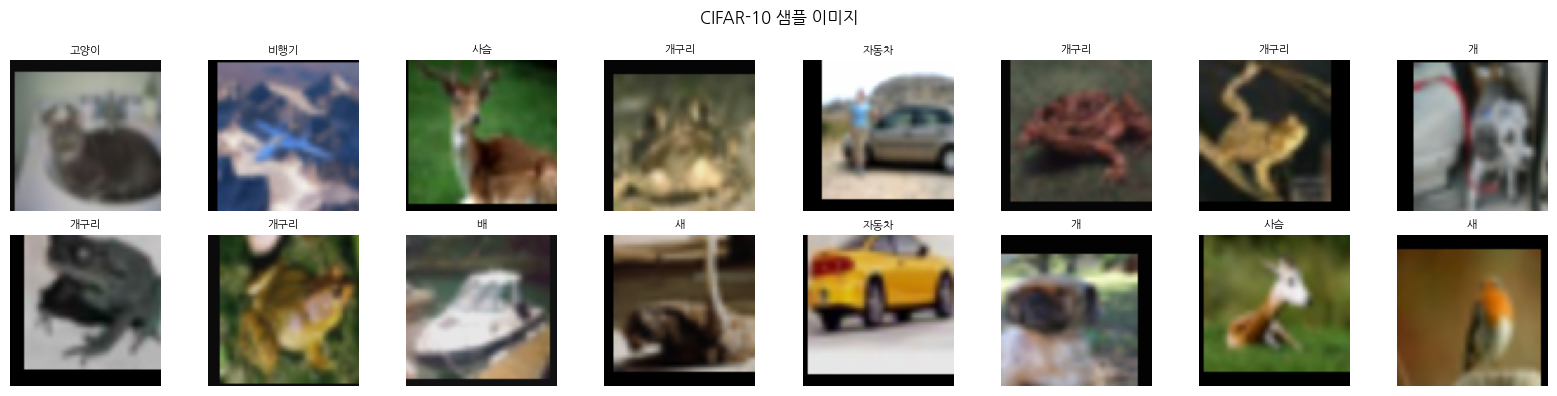

In [19]:
# ── 샘플 시각화 ──────────────────────────────────────────────────
imgs, lbs = next(iter(cifar_train_loader))
fig, axes = plt.subplots(2, 8, figsize=(16, 4))
for i, ax in enumerate(axes.ravel()):
    img = imgs[i].permute(1,2,0).numpy()
    img = img * [0.2470,0.2435,0.2616] + [0.4914,0.4822,0.4465]  # 역정규화
    ax.imshow(np.clip(img, 0, 1)); ax.axis('off')
    ax.set_title(CIFAR_CLASSES[lbs[i].item()], fontsize=8)
plt.suptitle('CIFAR-10 샘플 이미지', fontsize=12)
plt.tight_layout(); plt.show()

## 2-2. ResNet18 전이학습 모델 정의

In [20]:
# ── pretrained=True : ImageNet으로 미리 학습된 가중치 사용 ──────
model_cifar = models.resnet18(pretrained=True)

# Step 1 : 전체 파라미터 동결 (학습하지 않겠다는 선언)
for p in model_cifar.parameters():
    p.requires_grad = False

# Step 2 : layer4만 재학습 허용 (고수준 특징 미세조정)
for p in model_cifar.layer4.parameters():
    p.requires_grad = True

# Step 3 : 출력 레이어 교체 (ImageNet 1000클래스 → CIFAR-10 10클래스)
model_cifar.fc = nn.Linear(model_cifar.fc.in_features, 10)
# 새로 만든 fc는 requires_grad=True가 기본값

model_cifar = model_cifar.to(device)

# ── 학습 가능한 파라미터 비율 확인 ─────────────────────────────
trainable = sum(p.numel() for p in model_cifar.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model_cifar.parameters())
print(f"학습 파라미터: {trainable:,} / 전체: {total:,}  ({100*trainable/total:.1f}% 만 재학습)")

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 186MB/s]


학습 파라미터: 8,398,858 / 전체: 11,181,642  (75.1% 만 재학습)


## 2-3. 학습 함수 (다중 분류용)

PART 1과 거의 동일하지만, 예측 방식이 다릅니다:
- 이진 분류: `torch.sigmoid(out) >= 0.5`
- **다중 분류: `out.argmax(dim=1)`** — 가장 큰 로짓 값의 인덱스가 예측 클래스

In [21]:
def train_multi(model, criterion, optimizer, loader):
    model.train()
    total_loss, correct, n = 0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        out  = model(images)
        loss = criterion(out, labels)                # CrossEntropyLoss는 argmax 불필요
        loss.backward(); optimizer.step()
        total_loss += loss.item() * len(labels)
        correct += (out.argmax(dim=1) == labels).sum().item()  # 가장 큰 값의 인덱스
        n += len(labels)
    return total_loss / n, correct / n

@torch.no_grad()
def eval_multi(model, criterion, loader):
    model.eval()
    total_loss, correct, n = 0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        out  = model(images)
        loss = criterion(out, labels)
        total_loss += loss.item() * len(labels)
        correct += (out.argmax(dim=1) == labels).sum().item()
        n += len(labels)
    return total_loss / n, correct / n

## 2-4. 모델 학습

`StepLR` 스케줄러: 5 에폭마다 학습률을 절반으로 줄입니다.
학습 초반에는 큰 학습률로 빠르게 이동하고, 후반엔 작은 학습률로 섬세하게 수렴합니다.

In [23]:
# 11분 정도 걸려요!!!!
criterion_cifar = nn.CrossEntropyLoss()
# filter: requires_grad=True 인 파라미터만 전달 (동결된 파라미터 제외)
optimizer_cifar = optim.AdamW(
    filter(lambda p: p.requires_grad, model_cifar.parameters()),
    lr=1e-3, weight_decay=1e-4     # weight_decay: L2 정규화 (과적합 억제)
)
# StepLR: step_size마다 lr *= gamma
scheduler = optim.lr_scheduler.StepLR(optimizer_cifar, step_size=5, gamma=0.5)

cifar_train_losses, cifar_val_losses = [], []
cifar_train_accs,   cifar_val_accs   = [], []
best_val_cifar, patience, counter = float('inf'), 5, 0

for epoch in range(20):
    tl, ta = train_multi(model_cifar, criterion_cifar, optimizer_cifar, cifar_train_loader)
    vl, va = eval_multi (model_cifar, criterion_cifar, cifar_val_loader)
    scheduler.step()                                  # 스케줄러 업데이트
    cifar_train_losses.append(tl); cifar_val_losses.append(vl)
    cifar_train_accs.append(ta);   cifar_val_accs.append(va)
    print(f"Epoch {epoch+1:2d} | Train Loss:{tl:.4f} Acc:{ta:.4f} | Val Loss:{vl:.4f} Acc:{va:.4f} | LR:{scheduler.get_last_lr()[0]:.5f}")
    if vl < best_val_cifar:
        best_val_cifar = vl; counter = 0
        torch.save(model_cifar.state_dict(), 'cifar_best.pt')
        print(f"  ✅ Best 모델 저장!")
    else:
        counter += 1
        if counter >= patience: print("⏹️  조기 종료!"); break

print("\n학습 완료!")

Epoch  1 | Train Loss:0.8456 Acc:0.7081 | Val Loss:0.5825 Acc:0.8003 | LR:0.00100
  ✅ Best 모델 저장!
Epoch  2 | Train Loss:0.6423 Acc:0.7772 | Val Loss:0.5635 Acc:0.8044 | LR:0.00100
  ✅ Best 모델 저장!
Epoch  3 | Train Loss:0.5694 Acc:0.8040 | Val Loss:0.5194 Acc:0.8215 | LR:0.00100
  ✅ Best 모델 저장!
Epoch  4 | Train Loss:0.5242 Acc:0.8164 | Val Loss:0.4767 Acc:0.8357 | LR:0.00100
  ✅ Best 모델 저장!
Epoch  5 | Train Loss:0.4892 Acc:0.8303 | Val Loss:0.4923 Acc:0.8325 | LR:0.00050
Epoch  6 | Train Loss:0.4120 Acc:0.8541 | Val Loss:0.4376 Acc:0.8532 | LR:0.00050
  ✅ Best 모델 저장!
Epoch  7 | Train Loss:0.3815 Acc:0.8647 | Val Loss:0.4588 Acc:0.8426 | LR:0.00050
Epoch  8 | Train Loss:0.3637 Acc:0.8701 | Val Loss:0.4417 Acc:0.8518 | LR:0.00050
Epoch  9 | Train Loss:0.3458 Acc:0.8772 | Val Loss:0.4384 Acc:0.8547 | LR:0.00050
Epoch 10 | Train Loss:0.3266 Acc:0.8835 | Val Loss:0.4520 Acc:0.8532 | LR:0.00025
Epoch 11 | Train Loss:0.2756 Acc:0.9020 | Val Loss:0.4413 Acc:0.8590 | LR:0.00025
⏹️  조기 종료!

학습 완료!

## 2-5. 성능 평가 & Confusion Matrix

**Confusion Matrix** : 행 = 실제 클래스, 열 = 예측 클래스
대각선이 정답, 대각선 밖이 오분류입니다.
어떤 클래스끼리 헷갈리는지(예: 고양이 ↔ 개) 한눈에 파악할 수 있습니다.

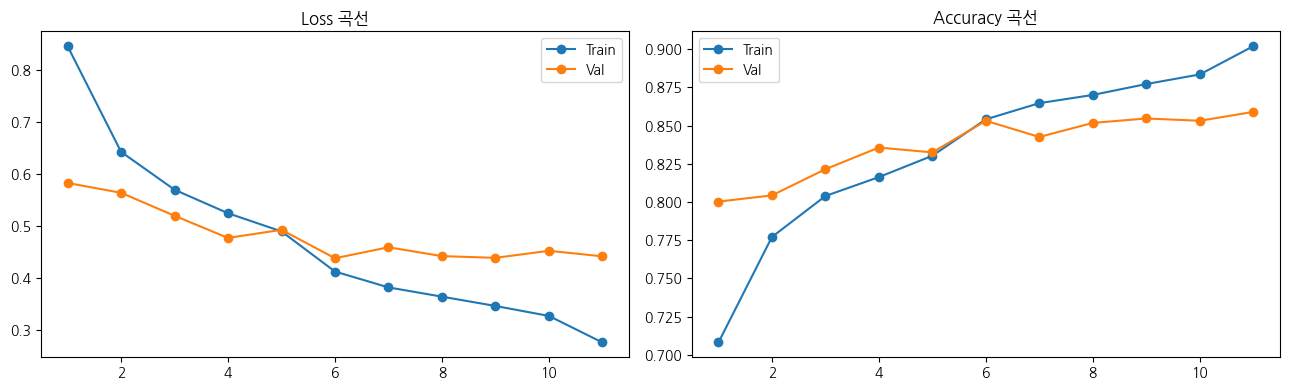

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
ep = range(1, len(cifar_train_losses)+1)
axes[0].plot(ep, cifar_train_losses, marker='o', label='Train')
axes[0].plot(ep, cifar_val_losses,   marker='o', label='Val')
axes[0].set_title('Loss 곡선'); axes[0].legend()
axes[1].plot(ep, cifar_train_accs, marker='o', label='Train')
axes[1].plot(ep, cifar_val_accs,   marker='o', label='Val')
axes[1].set_title('Accuracy 곡선'); axes[1].legend()
plt.tight_layout(); plt.show()

🎯 테스트 Loss: 0.4400  |  테스트 Accuracy: 0.8528


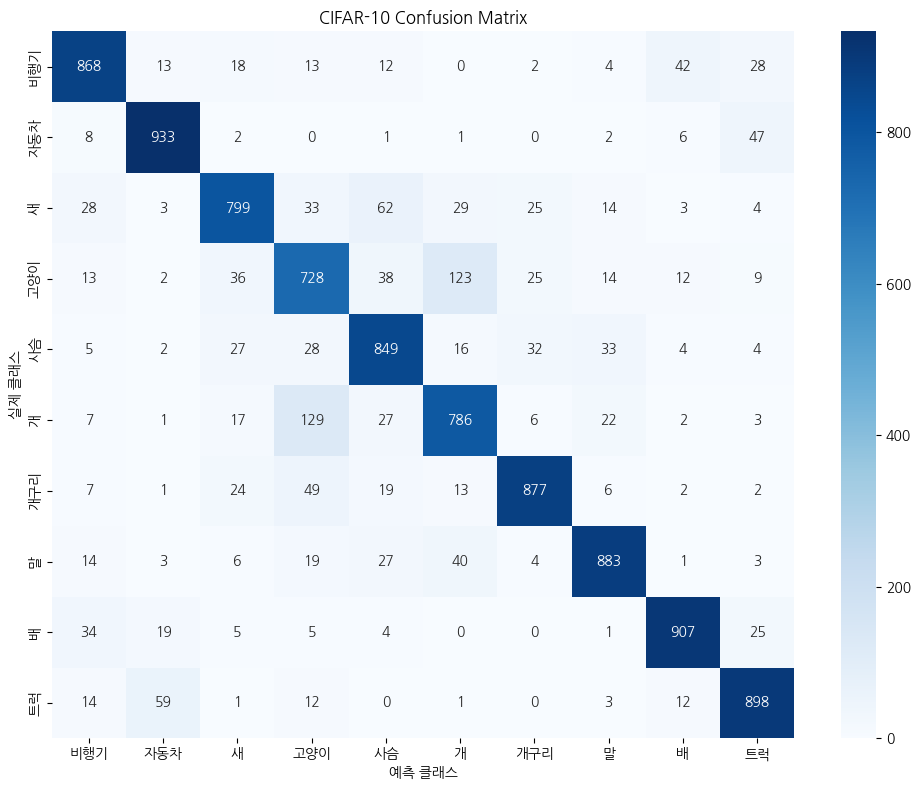

In [25]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# ── Best 모델 로드 후 테스트 평가 ────────────────────────────────
model_cifar.load_state_dict(torch.load('cifar_best.pt', map_location=device))
test_loss, test_acc = eval_multi(model_cifar, criterion_cifar, cifar_test_loader)
print(f"🎯 테스트 Loss: {test_loss:.4f}  |  테스트 Accuracy: {test_acc:.4f}")

# ── Confusion Matrix 계산 ────────────────────────────────────────
all_preds, all_labels = [], []
model_cifar.eval()
with torch.no_grad():
    for imgs, lbs in cifar_test_loader:
        preds = model_cifar(imgs.to(device)).argmax(1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(lbs.numpy())

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CIFAR_CLASSES, yticklabels=CIFAR_CLASSES)
plt.title('CIFAR-10 Confusion Matrix')
plt.ylabel('실제 클래스'); plt.xlabel('예측 클래스')
plt.tight_layout(); plt.show()

# 📚 시퀀스 모델 이론 — RNN / LSTM / GRU
### 아래 질문에 답을 채워주세요!

## 1. Keras와 순환 신경망(RNN) 기초

시퀀스 데이터는 '순서'가 중요한 데이터입니다.
RNN(Recurrent Neural Network)은 이 순서를 기억하기 위해 '상태(state)'를 가지는 신경망입니다.

> **시퀀스(순차) 데이터의 큰 특징 두 가지는?**
> - 답1: 순서 의존성
> - 답2: 길이 가변성

이러한 특징들로 인해 기존의 머신러닝 기법으로 시계열 데이터를 다루는 것은 한계가 있습니다.
과거의 정보를 기억하고, 순서의 의미를 학습할 수 있어 시퀀스 데이터 처리에 특화된 신경망이 **RNN**입니다!

> **RNN이 사용하는 세 가지 가중치는?**
> - 답1: 입력
> - 답2: 순환
> - 답3: 출력

**RNN의 핵심 원리는?? : 파라미터 공유(Parameter Sharing) — 동일한 가중치를 시퀀스의 모든 시점에서 반복 적용

간략한 설명: 동일한 가중치를 시퀀스의 다양한 시점에서 반복적으로 적용하게 하는 것.
$X_1, X_2, ..., X_n$을 처리할 때까지 모두 동일한 파라미터(입력 가중치(U), 순환 가중치(V), 편향(b))를 공유하는 구조

---

### 기본 RNN의 세 가지 구조적 한계점

| 한계점 | 설명 |
|:---:|:---|
| 기울기 소실 | 시퀀스 뒤쪽의 오차가 앞쪽까지 제대로 전달되지 않아 먼 과거의 정보를 학습하지 못하는 현상 → 기울기가 0으로 수렴 |
| 기울기 폭주 | 시퀀스 뒤쪽의 오차가 역전파 과정에서 비정상적으로 커지는 문제 → 기울기가 무한으로 발산 |
| 느린 훈련 시간 | $t$ 시점의 은닉 상태($h_t$)를 계산하려면 $(t-1)$ 시점의 은닉 상태($h_{t-1}$)가 먼저 계산되어야 함 → 이 의존성 때문에 전체 시퀀스를 한 번에 병렬 처리 불가능 |

> 이 세 가지 한계점으로 인해 RNN은 '장기 기억력 문제'를 갖게 됩니다.

**→ 중요한 정보는 오래 기억하고, 불필요한 정보는 잊는 '똑똑한' 모델이 필요하게 되겠죠!**

---

## 2. LSTM (Long Short-Term Memory)

LSTM의 핵심 아이디어는 셀 상태(Cell State)를 따로 두는 것입니다.
LSTM은 3개의 주요 게이트를 통해 셀 상태(기억)를 관리합니다.

### 🗑️ Forget Gate (잊기 게이트)

- **역할** : 과거의 정보($C_{t-1}$) 중에서 얼마나 잊어버릴지 결정합니다.
- **동작** : 이전 시점의 출력($h_{t-1}$)과 현재 시점의 입력($x_t$)을 받아 0에서 1 사이의 값을 출력합니다. (1이면 완전히 기억, 0이면 완전히 잊음)

> 예: 문장에서 주어가 바뀌면, 이전 주어에 대한 정보를 잊도록(0에 가깝게) 신호를 보냅니다.

### 🔼 Input Gate (입력 게이트)

- **역할** : 현재 시점의 정보($x_t$) 중에서 얼마나 셀 상태에 저장할지 결정합니다.
- **동작** :
  1. 어떤 정보를 추가할지 후보($\tilde{C}_t$)를 만듭니다. (tanh 사용)
  2. 그 후보 정보를 얼마나(비율로) 추가할지 결정합니다. (sigmoid 사용)

> 예: 새로운 주어가 등장하면, 이 정보를 셀 상태에 추가하도록(1에 가깝게) 신호를 보냅니다.

> **Final memory cell의 계산:**
> $C_t$ = ( Forget Gate의 출력 $\times$ $C_{t-1}$(이전 셀 상태) ) + ( Input Gate의 출력 $\times$ $\tilde{C}_t$(새로운 후보 정보) )

### 🔽 Output Gate (출력 게이트)

- **역할** : 업데이트된 셀 상태($C_t$)의 정보 중에서 무엇을 현재 시점의 출력($h_t$)으로 내보낼지 결정합니다.
- **동작** : 셀 상태의 정보가 모두 다음 시점으로 전달될 필요는 없습니다. 현재 시점의 예측에 필요한 정보만 필터링하여 출력합니다.

> LSTM은 별도의 '셀 상태'를 통해 장기 기억을 보존하고, 3개의 게이트를 통해 이 기억을 선택적으로 잊거나, 추가하거나, 출력합니다.
> 이 구조 덕분에 **기울기가 소실되지 않고** 먼 과거까지 전달될 수 있습니다.

---

## 3. GRU (Gated Recurrent Unit)

GRU는 LSTM의 '셀 상태'와 '은닉 상태'를 하나($h_t$)로 통합하고, 게이트도 2개로 줄였습니다.

### 🔄 Reset Gate (리셋 게이트)

- **역할** : 과거 정보($h_{t-1}$)를 얼마나 무시할지 결정합니다.
- **동작** : 이 게이트가 0에 가까우면, 이전 시점의 상태($h_{t-1}$)를 거의 무시하고 현재 입력($x_t$)만으로 새로운 상태를 만들 준비를 합니다.

> LSTM의 'Forget Gate'와 유사하지만, 새로운 후보를 만들 때 관여합니다.

### 🔼 Update Gate (업데이트 게이트)

- **역할** : 과거 정보와 현재 정보의 갱신 비율을 결정합니다. (LSTM의 Forget 게이트와 Input 게이트를 하나로 합친 역할)
- **동작** :
  - 이 게이트의 값($z_t$)이 1에 가까우면: 과거 정보를 많이 무시하고, 새로운 정보($\tilde{h}_t$)를 많이 반영합니다.
  - 이 게이트의 값($z_t$)이 0에 가까우면: 새로운 정보를 무시하고, 과거 정보($h_{t-1}$)를 그대로 가져옵니다.

> GRU는 구조가 더 단순하여 LSTM보다 파라미터 수가 적고 계산 속도가 빠르면서도,
> LSTM과 비슷한, 혹은 더 좋은 성능을 보여주기도 합니다.

---

## 4. Keras로 구현하기

Keras는 PyTorch에 비해 사용법이 매우 직관적입니다.

- **Keras** (본 과제에서 사용): `model.fit()`, `model.compile()`처럼 자주 쓰이는 기능들이 미리 정의되어 있습니다. 모델을 빠르게 학습시키고, 데이터의 입력부터 출력까지의 전체 흐름을 파악하는 데 유리합니다.
- **PyTorch** (실습 세션에서 사용했었죠): 모델의 아주 세밀한 동작(루프, 커스터마이징, 가중치 제어 등)을 직접 구현해야 할 때가 많습니다. 이는 미세한 튜닝이나 연구 분야에서 더 강력한 유연성을 보여줍니다.

이번 과제의 목표는 **Keras를 통해 RNN과 LSTM의 핵심 개념을 빠르게 구현하고 경험하는 것**입니다.

Keras는 `layers.SimpleRNN`, `layers.LSTM`, `layers.GRU`처럼 강력한 순환 레이어를 단 한 줄의 코드로 제공합니다.
예를 들어, LSTM 레이어 하나를 추가하는 것은 PyTorch에서는 여러 줄의 설정이 필요할 수 있지만, Keras에서는 단지 `layers.LSTM(64)` 한 줄이면 끝납니다.

우리는 이 '블록'들을 가져와서 실제 시퀀스 데이터(텍스트, 시계열 등)에 어떻게 적용하는지 그 흐름을 파악하는 데 집중할 것입니다.

> 'Keras로 RNN/LSTM을 사용하니 이렇게 간단하게 시퀀스 모델이 만들어지는구나!' 하는 경험과 직관을 얻어가는 시간으로 생각하고, 즐겁게 코드를 채워주세요!

In [26]:
# Keras로 만드는 LSTM 레이어 예시
# Keras의 RNN 레이어는 (batch_size, timesteps, features) 형태의 입력을 기대합니다.

# 가상의 시퀀스 데이터 생성
# 예: 32개의 문장(batch_size), 각 문장은 10개의 단어(timesteps), 각 단어는 8차원의 벡터(features)
input_shape = (10, 8)
dummy_input = np.random.rand(32, *input_shape)

# LSTM 레이어 생성 (64개의 유닛)
lstm_layer = layers.LSTM(64)
output = lstm_layer(dummy_input)

print(f"입력 크기: {dummy_input.shape}")
print(f"LSTM 출력 크기: {output.shape}") # 마지막 타임스텝의 출력만 반환

# return_sequences=True: 모든 타임스텝의 출력을 반환 (RNN을 층층이 쌓을 때 필요)
lstm_layer_seq = layers.LSTM(64, return_sequences=True)
output_seq = lstm_layer_seq(dummy_input)
print(f"LSTM (seq=True) 출력 크기: {output_seq.shape}")

입력 크기: (32, 10, 8)
LSTM 출력 크기: (32, 64)
LSTM (seq=True) 출력 크기: (32, 10, 64)


---

# 📝 PART 3. LSTM 텍스트 감성 분석 (IMDB, Keras)

가장 고전적인 NLP(자연어 처리) 과제 중 하나입니다. 영화 리뷰 텍스트를 보고 긍정/부정을 분류합니다.

이번에는 텍스트를 딥러닝으로 처리하는 가장 표준적인 두 가지 기술을 배웁니다.

**1. Embedding (임베딩) 레이어**  
- 왜 필요할까요?  
컴퓨터는 'good', 'bad' 같은 텍스트 단어를 직접 이해할 수 없습니다. 모든 것을 숫자로 바꿔주어야 합니다.

- 어떻게 작동하나요?  
  a. 단어를 숫자로 매핑: Embedding 레이어는 데이터에 있는 고유한 단어들 각각에 고유한 번호(인덱스)를 부여합니다.  
  b. 숫자를 '벡터'로 변환: 그 다음, 이 번호(인덱스)를 **Dense Vector**로 변환합니다. (예: 128차원의 숫자 배열)  
  > good (단어) ➔ 5 (인덱스) ➔ [0.1, 0.5, -0.2, ... , 0.9] (128차원 벡터)

  c. '의미'를 학습: 이 벡터는 단순한 ID가 아닙니다. 모델이 훈련하는 과정에서 단어의 '의미'를 학습합니다. 그 결과, 'good'과 'great', 'fantastic'은 벡터 공간에서 서로 '가까운' 위치에, 'good'과 'terrible', 'awful' 같은 단어들은 '먼' 위치에 자리 잡게 됩니다.

> 즉, Embedding은 텍스트를 컴퓨터가 이해할 수 있는 '의미가 담긴' 숫자 벡터로 바꿔주는 필수적인 첫 단계입니다.

<br><br>
**2. Bidirectional LSTM (양방향 LSTM)**  
- 왜 그냥 LSTM이 아니라 '양방향'을 쓸까요?  
RNN과 LSTM은 텍스트와 같은 시퀀스 데이터를, 앞에서부터(왼쪽에서 오른쪽으로) 차례대로 읽으며 '기억'(Context)을 쌓아갑니다.

  **하지만 문장의 진짜 의미는 뒤에 나오는 단어에 의해 결정될 때가 많습니다.**

  예시 1: "This movie was not bad at all."

  "bad"만 보면 부정적이지만, 앞에 "not"이 있습니다.

  예시 2: "The visual effects were stunning, but the story was terrible."

  "stunning" 때문에 긍정으로 판단하다가, 마지막 "terrible"을 보고 부정으로 결론 내려야 합니다.

- 어떻게 작동하나요?  
Bidirectional 래퍼(Wrapper)는 LSTM 레이어를 두 개 만듭니다.

  - 정방향 (Forward) LSTM: 텍스트를 "I loved this movie" 순서 (앞 -> 뒤)로 읽습니다.

  - 역방향 (Backward) LSTM: 텍스트를 "movie this loved I" 순서 (뒤 -> 앞)로 읽습니다.

  모델은 이 두 방향의 '기억(출력)'을 모두 합쳐서 최종 결정을 내립니다.

> 그 결과, 모델은 각 단어의 '앞뒤 문맥'을 완벽하게 파악할 수 있게 되어, 훨씬 더 정확하게 긍정/부정을 분류할 수 있습니다.

---

## 3-1. 데이터 로드 및 전처리

In [27]:
# ── IMDB 내장 데이터셋 로드 ─────────────────────────────────────
# num_words=20000 : 빈도 상위 20,000개 단어만 사용 (나머지는 <unk> 처리)
max_features = 20000
maxlen       = 200     # 각 리뷰를 200 토큰으로 통일 (짧으면 패딩, 길면 자름)

(X_train, y_train), (X_val, y_val) = keras.datasets.imdb.load_data(num_words=max_features)
print(f"훈련: {len(X_train)}개  |  검증: {len(X_val)}개")
print(f"첫 번째 리뷰 (정수 인코딩): {X_train[0][:15]}...")
print(f"레이블: {y_train[0]} ({'긍정' if y_train[0]==1 else '부정'})")

# ── 패딩 (Padding) ───────────────────────────────────────────────
# 리뷰마다 길이가 다름 → 배치 처리를 위해 동일한 길이로 맞춤
# 짧은 리뷰는 앞을 0으로 채움 (pre-padding), 긴 리뷰는 앞을 자름
X_train = keras.preprocessing.sequence.pad_sequences(X_train, maxlen=maxlen)
X_val   = keras.preprocessing.sequence.pad_sequences(X_val,   maxlen=maxlen)
print(f"\n패딩 후 shape: {X_train.shape}")  # (25000, 200)

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
훈련: 25000개  |  검증: 25000개
첫 번째 리뷰 (정수 인코딩): [1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4]...
레이블: 1 (긍정)

패딩 후 shape: (25000, 200)


## 3-2. Bidirectional LSTM 모델 구축

Keras의 **함수형 API** (Functional API) 방식으로 모델을 정의합니다.
```
Input → Embedding → BiLSTM(return_sequences=True) → BiLSTM → Dropout → Dense(sigmoid)
```

`return_sequences=True` : 각 타임스텝의 출력을 모두 반환 → 다음 LSTM 레이어로 전달
`return_sequences=False` (기본값) : 마지막 타임스텝 출력만 반환 → FC 레이어로 전달

In [30]:
# ── 모델 구성 ───────────────────────────────────────────────────
inputs_imdb = keras.Input(shape=(None,), dtype="int32")   # 가변 길이 정수 시퀀스

# Embedding : (배치, 시퀀스길이) → (배치, 시퀀스길이, 128)
x = layers.Embedding(max_features, 128)(inputs_imdb)

# 1층 BiLSTM : 각 타임스텝 출력 모두 반환 (return_sequences=True)
x = layers.Bidirectional(layers.LSTM(64, return_sequences=True))(x)

# 2층 BiLSTM : 마지막 타임스텝 출력만 반환
x = layers.Bidirectional(layers.LSTM(64))(x)

x = layers.Dropout(0.3)(x)   # 과적합 방지

# 이진 분류 → 출력 1개, Sigmoid 활성화
outputs_imdb = layers.Dense(1, activation="sigmoid")(x)

model_imdb = keras.Model(inputs_imdb, outputs_imdb)
model_imdb.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, None)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_2 (Embedding)         │ (None, None, 128)      │     2,560,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_4 (Bidirectional) │ (None, None, 128)      │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_5 (Bidirectional) │ (None, 128)            │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,757,761 (10.52 MB)

 Trainable params: 2,757,761 (10.52 MB)

 Non-trainable params: 0 (0.00 B)

## 3-3. 학습 및 결과

In [31]:
model_imdb.compile(
    optimizer="adam",
    loss="binary_crossentropy",   # 이진 분류 손실 (Keras에서는 Sigmoid 이후이므로 BCE 사용)
    metrics=["accuracy"]
)

imdb_fit = model_imdb.fit(
    X_train, y_train,
    batch_size=128,
    epochs=5,
    validation_data=(X_val, y_val)
)

Epoch 1/5
196/196 ━━━━━━━━━━━━━━━━━━━━ 20s 64ms/step - accuracy: 0.7772 - loss: 0.4499 - val_accuracy: 0.8544 - val_loss: 0.3489
Epoch 2/5
196/196 ━━━━━━━━━━━━━━━━━━━━ 17s 60ms/step - accuracy: 0.9102 - loss: 0.2357 - val_accuracy: 0.8596 - val_loss: 0.3258
Epoch 3/5
196/196 ━━━━━━━━━━━━━━━━━━━━ 12s 59ms/step - accuracy: 0.9448 - loss: 0.1548 - val_accuracy: 0.8560 - val_loss: 0.3527
Epoch 4/5
196/196 ━━━━━━━━━━━━━━━━━━━━ 12s 59ms/step - accuracy: 0.9697 - loss: 0.0950 - val_accuracy: 0.8582 - val_loss: 0.4408
Epoch 5/5
196/196 ━━━━━━━━━━━━━━━━━━━━ 12s 59ms/step - accuracy: 0.9814 - loss: 0.0596 - val_accuracy: 0.8453 - val_loss: 0.5436


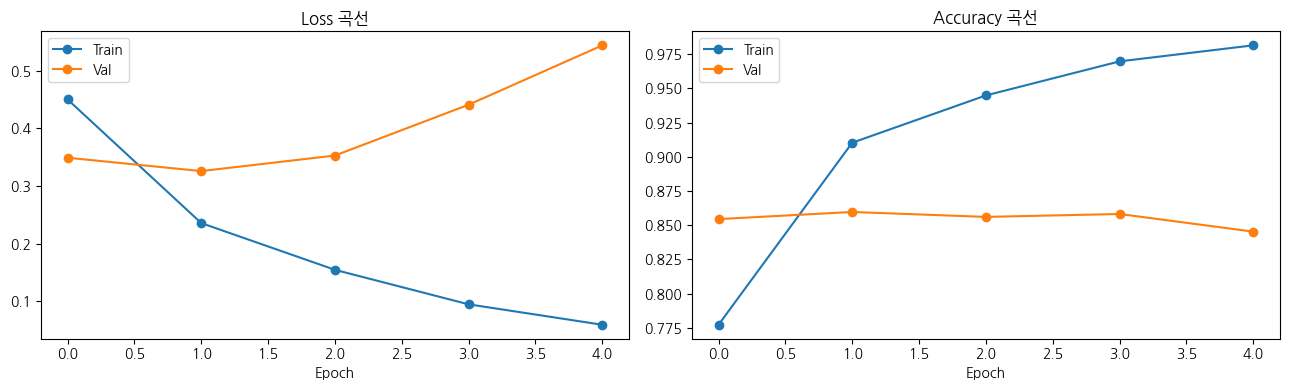

최종 Val Accuracy: 0.8453


In [32]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(imdb_fit.history['loss'],     marker='o', label='Train')
axes[0].plot(imdb_fit.history['val_loss'], marker='o', label='Val')
axes[0].set_title('Loss 곡선'); axes[0].set_xlabel('Epoch'); axes[0].legend()

axes[1].plot(imdb_fit.history['accuracy'],     marker='o', label='Train')
axes[1].plot(imdb_fit.history['val_accuracy'], marker='o', label='Val')
axes[1].set_title('Accuracy 곡선'); axes[1].set_xlabel('Epoch'); axes[1].legend()

plt.tight_layout(); plt.show()
print(f"최종 Val Accuracy: {imdb_fit.history['val_accuracy'][-1]:.4f}")

## 3-4. 직접 리뷰 입력해서 예측해보기

학습된 모델로 새로운 문장을 분류해봅니다.
내부적으로는 단어 → 정수 인코딩 → 패딩 → 모델 예측 순서로 진행됩니다.

In [33]:
# ── 단어 사전 로드 (단어 → 정수 변환용) ────────────────────────
word_index = keras.datasets.imdb.get_word_index()
# IMDB 단어 사전 로드 (단어 → 정수 인덱스)
# 예: {"the": 1, "a": 2, "good": 50, ...}
word_index = {k: v for k, v in word_index.items()}

def predict_review(text):
    tokens = []
    for w in text.lower().split():       # 소문자 변환 후 단어 단위로 분리
        idx = word_index.get(w, 2)       # 사전에 없는 단어는 <unk>=2로 처리
        if idx < max_features:           # 상위 20,000개 단어 안에 있는 경우만 사용
            tokens.append(idx)
        else:
            tokens.append(2)             # 범위 밖 단어도 <unk>=2로 처리
    # 모든 리뷰를 동일한 길이(200)로 맞춤 (짧으면 앞을 0으로 패딩)
    padded = keras.preprocessing.sequence.pad_sequences([tokens], maxlen=maxlen)
    # 모델 예측 (0~1 사이 확률값 반환)
    score  = model_imdb.predict(padded, verbose=0)[0][0]
    print(f"입력 : {text}")
    print(f"점수 : {score:.4f}  →  {'긍정 😊' if score > 0.5 else '부정 😞'}\n")

# 다양한 리뷰 테스트 해보세요!!! (예시 말구... 바꿔서 해보세요!!!! 꼭!!)
# 긍정 리뷰 테스트
predict_review("I absolutely loved this movie, it was fantastic and heartwarming!")
# 부정 리뷰 테스트
predict_review("This movie was a complete waste of time, terribly boring and dull.")
# 중립 리뷰 테스트
predict_review("It was okay, not the best but not the worst either.")

1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
입력 : I absolutely loved this movie, it was fantastic and heartwarming!
점수 : 0.9239  →  긍정 😊

입력 : This movie was a complete waste of time, terribly boring and dull.
점수 : 0.8106  →  긍정 😊

입력 : It was okay, not the best but not the worst either.
점수 : 0.0200  →  부정 😞



---

# 🌡️ PART 4. LSTM 시계열 기온 예측 (예나 기후, Keras)

독일 예나(Jena)의 기후 데이터로 **6시간 뒤의 기온**을 예측합니다.
과거 5일치(120시간) 14개 기상 피처 → 미래 기온 (**다변량 회귀 예측**)

## 🔑 핵심 개념

### 시계열 데이터 처리 주의사항

> ⚠️ **랜덤 분할 절대 금지!**

시계열 데이터를 랜덤으로 섞으면 **미래 데이터가 학습에 사용**되는 데이터 누수(Data Leakage)가 발생합니다.
반드시 **시간 순서대로 분할**해야 합니다.

```
전체 데이터 (시간 순서)
├── 0% ~ 70%  : 훈련 셋
├── 70% ~ 90% : 검증 셋
└── 90% ~ 100%: 테스트 셋
```

### 슬라이딩 윈도우 방식

```
[t=0 ~ t=119] → 예측: t=125
[t=1 ~ t=120] → 예측: t=126
[t=2 ~ t=121] → 예측: t=127
...
```

하나의 데이터로 여러 학습 샘플을 만들 수 있습니다.

### 정규화 주의사항
검증/테스트 셋 정규화에도 **훈련 셋의 평균/표준편차**를 사용해야 합니다.
그렇지 않으면 미래 통계값이 학습에 영향을 미쳐 데이터 누수가 됩니다.

---

## 4-1. 데이터 로드

> 📁 `jena_climate_2009_2016.csv` 파일이 필요합니다!!! (git, 노션에 다 있습니다)

In [35]:
# ── 구글 드라이브 마운트 (처음 실행 시 인증 필요) ────────────────
from google.colab import drive
drive.mount('/content/drive')

# ── 파일 경로를 본인 환경에 맞게 수정하세요 ─────────────────────
file_path = "/content/jena_climate_2009_2016.csv"

df = pd.read_csv(file_path)
df['Date Time'] = pd.to_datetime(df['Date Time'], format='%d.%m.%Y %H:%M:%S')
df.set_index('Date Time', inplace=True)

# 원래 10분 간격 → 1시간 간격으로 다운샘플링 (6배 간격으로 추출)
df = df[::6]

print(f"데이터 형태: {df.shape}")
print(f"기간: {df.index[0]} ~ {df.index[-1]}")
print("\n컬럼 목록:")
print(list(df.columns))
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
데이터 형태: (70092, 14)
기간: 2009-01-01 00:10:00 ~ 2016-12-31 23:20:00

컬럼 목록:
['p (mbar)', 'T (degC)', 'Tpot (K)', 'Tdew (degC)', 'rh (%)', 'VPmax (mbar)', 'VPact (mbar)', 'VPdef (mbar)', 'sh (g/kg)', 'H2OC (mmol/mol)', 'rho (g/m**3)', 'wv (m/s)', 'max. wv (m/s)', 'wd (deg)']


,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
Date Time,,,,,,,,,,,,,,
2009-01-01 00:10:00,996.52,-8.02,265.40,-8.90,93.3,3.33,3.11,0.22,1.94,3.12,1307.75,1.03,1.75,152.3
2009-01-01 01:10:00,996.50,-7.62,265.81,-8.30,94.8,3.44,3.26,0.18,2.04,3.27,1305.68,0.18,0.63,166.5
2009-01-01 02:10:00,996.63,-8.85,264.57,-9.70,93.5,3.12,2.92,0.20,1.82,2.93,1312.11,0.16,0.50,158.3
2009-01-01 03:10:00,996.87,-8.84,264.56,-9.69,93.5,3.13,2.92,0.20,1.83,2.93,1312.37,0.07,0.25,129.3
2009-01-01 04:10:00,997.05,-9.23,264.15,-10.25,92.2,3.03,2.79,0.24,1.74,2.80,1314.62,0.10,0.38,203.9


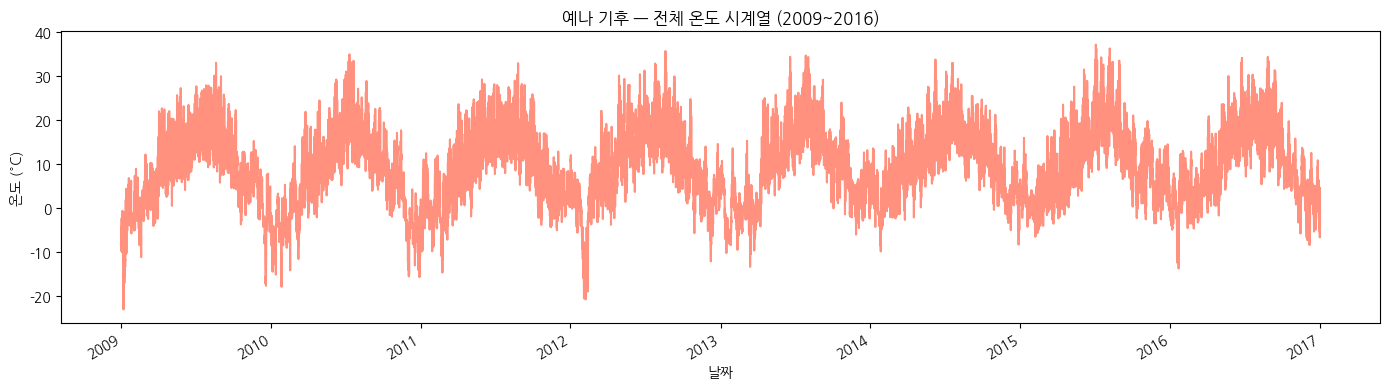

온도 범위: -23.0°C ~ 37.1°C


In [36]:
# ── 전체 온도 시계열 시각화 ─────────────────────────────────────
df['T (degC)'].plot(figsize=(14, 4), color='tomato', alpha=0.7)
plt.title('예나 기후 — 전체 온도 시계열 (2009~2016)')
plt.ylabel('온도 (°C)'); plt.xlabel('날짜')
plt.tight_layout(); plt.show()
print(f"온도 범위: {df['T (degC)'].min():.1f}°C ~ {df['T (degC)'].max():.1f}°C")

## 4-2. 데이터 분리 및 정규화

In [37]:
target_col = 'T (degC)'
X = df.drop(columns=[target_col])   # 피처 (13개)
y = df[target_col].values           # 타깃 (예측할 온도)

n = len(df)
train_end = int(n * 0.7)
val_end   = int(n * 0.9)

# ── 반드시 훈련 셋 통계로만 정규화! ─────────────────────────────
train_mean = X.values[:train_end].mean()
train_std  = X.values[:train_end].std()
X_norm     = (X - train_mean) / train_std  # Z-score 정규화

X_data = X_norm.values
X_train, y_train = X_data[:train_end],       y[:train_end]
X_val,   y_val   = X_data[train_end:val_end], y[train_end:val_end]
X_test,  y_test  = X_data[val_end:],          y[val_end:]

print(f"Train : {X_train.shape}  |  y_train: {y_train.shape}")
print(f"Val   : {X_val.shape}    |  y_val:   {y_val.shape}")
print(f"Test  : {X_test.shape}   |  y_test:  {y_test.shape}")

Train : (49064, 13)  |  y_train: (49064,)
Val   : (14018, 13)    |  y_val:   (14018,)
Test  : (7010, 13)   |  y_test:  (7010,)


## 4-3. 슬라이딩 윈도우 데이터셋 생성

`keras.utils.timeseries_dataset_from_array`가 슬라이딩 윈도우를 자동으로 만들어줍니다.

- `sequence_length=120` : 120시간(5일)을 입력으로 사용
- `delay=6` : 6시간 뒤의 온도를 예측 (입력 끝 시점 기준)

> X[:-6]과 y[6:]을 넘기면 자동으로 시점이 맞춰집니다.

In [38]:
sequence_length = 120   # 과거 120시간 (5일)
delay          = 6     # 6시간 뒤 예측
batch_size     = 256

def make_tf_dataset(X, y, seq_len, delay, batch_size, shuffle=False):
    # X[:-delay] : 딜레이만큼 앞부분 피처
    # y[delay:]  : 딜레이만큼 뒤로 밀린 타깃
    return keras.utils.timeseries_dataset_from_array(
        X[:-delay], y[delay:],
        sequence_length=seq_len,
        sampling_rate=1,          # 매 타임스텝 사용
        sequence_stride=1,        # 윈도우를 1씩 이동
        batch_size=batch_size,
        shuffle=shuffle
    )

train_tf = make_tf_dataset(X_train, y_train, sequence_length, delay, batch_size, shuffle=True)
val_tf   = make_tf_dataset(X_val,   y_val,   sequence_length, delay, batch_size)
test_tf  = make_tf_dataset(X_test,  y_test,  sequence_length, delay, batch_size)

for batch in train_tf.take(1):
    print(f"입력 shape: {batch[0].shape}  ← (배치, 120타임스텝, 13피처)")
    print(f"타깃 shape: {batch[1].shape}  ← (배치,)")

입력 shape: (256, 120, 13)  ← (배치, 120타임스텝, 13피처)
타깃 shape: (256,)  ← (배치,)


## 4-4. LSTM 모델 구축 및 학습


회귀 문제이므로 출력 레이어에 **활성화 함수 없음**, 손실 함수는 **MSE** (평균 제곱 오차)를 사용합니다.
평가 지표로 **MAE** (평균 절대 오차, 단위: °C)를 함께 확인합니다.

이제 (120, 13) 형태의 입력을 받아 (1,) 형태의 출력을 내보내는 모델을 만듭니다.  
여기서는 추가로 EarlyStopping이라는 툴을 써 볼게요.

In [39]:
from tensorflow.keras.callbacks import EarlyStopping

# ── 2층 Stacked LSTM ─────────────────────────────────────────────
inputs_jena = keras.Input(shape=(sequence_length, X_train.shape[-1]))

# 1층: return_sequences=True → 다음 LSTM에 시퀀스 전달
x = layers.LSTM(64, activation='tanh', return_sequences=True)(inputs_jena)

# 2층: return_sequences=False (기본) → 마지막 hidden state만 출력
x = layers.LSTM(32, activation='tanh')(x)

# Dropout 레이어: 과적합 방지
x = layers.Dropout(0.2)(x)
# 0.2는 Dropout rate로, 학습 시 랜덤하게 전체 뉴런의 20%를 꺼서 과적합을 방지합니다.


# 회귀 출력 : 활성화 함수 없음 (임의 실수값 출력)
outputs_jena = layers.Dense(1)(x)

model_jena = keras.Model(inputs_jena, outputs_jena)
# 2. 모델 컴파일 ('회귀' 문제)
# 손실(Loss): Mean Squared Error (평균 제곱 오차)
# 지표(Metric): Mean Absolute Error (평균 절대 오차)
model_jena.compile(
    optimizer='adam',
    loss='mse',           # Mean Squared Error
    metrics=['mae']       # Mean Absolute Error (해석이 쉬움: °C 단위)
)
model_jena.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 120, 13)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_8 (LSTM)                   │ (None, 120, 64)        │        19,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_9 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 32,417 (126.63 KB)

 Trainable params: 32,417 (126.63 KB)

 Non-trainable params: 0 (0.00 B)

In [40]:
# 과적합을 막기 위한 EarlyStopping 객체
# val_loss가 더 이상 좋아지지 않고 몇 번 연속으로 나빠지면, 100번을 다 채우기 전에 훈련을 "조기 종료" 하는 과적합 방지 기법입니다.
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True  # 학습 종료 시 Best 가중치로 자동 복원
)
# 모델 학습
history_jena = model_jena.fit(
    train_tf,
    epochs=100,
    validation_data=val_tf,
    callbacks=[early_stop]
)

Epoch 1/100
192/192 ━━━━━━━━━━━━━━━━━━━━ 16s 63ms/step - loss: 81.2819 - mae: 7.3050 - val_loss: 58.7242 - val_mae: 6.2862
Epoch 2/100
192/192 ━━━━━━━━━━━━━━━━━━━━ 10s 51ms/step - loss: 75.4245 - mae: 7.0572 - val_loss: 58.6270 - val_mae: 6.2817
Epoch 3/100
192/192 ━━━━━━━━━━━━━━━━━━━━ 10s 50ms/step - loss: 75.4311 - mae: 7.0531 - val_loss: 58.5668 - val_mae: 6.2830
Epoch 4/100
192/192 ━━━━━━━━━━━━━━━━━━━━ 11s 57ms/step - loss: 75.2267 - mae: 7.0454 - val_loss: 58.6448 - val_mae: 6.2714
Epoch 5/100
192/192 ━━━━━━━━━━━━━━━━━━━━ 12s 61ms/step - loss: 75.1771 - mae: 7.0410 - val_loss: 58.3870 - val_mae: 6.2740
Epoch 6/100
192/192 ━━━━━━━━━━━━━━━━━━━━ 11s 54ms/step - loss: 73.4474 - mae: 6.9538 - val_loss: 78.4228 - val_mae: 7.0610
Epoch 7/100
192/192 ━━━━━━━━━━━━━━━━━━━━ 10s 52ms/step - loss: 75.7686 - mae: 7.0728 - val_loss: 58.4833 - val_mae: 6.2813
Epoch 8/100
192/192 ━━━━━━━━━━━━━━━━━━━━ 12s 62ms/step - loss: 75.7193 - mae: 7.0672 - val_loss: 60.9265 - val_mae: 6.3398
Epoch 9/100
192/

## 4-5. 결과 시각화

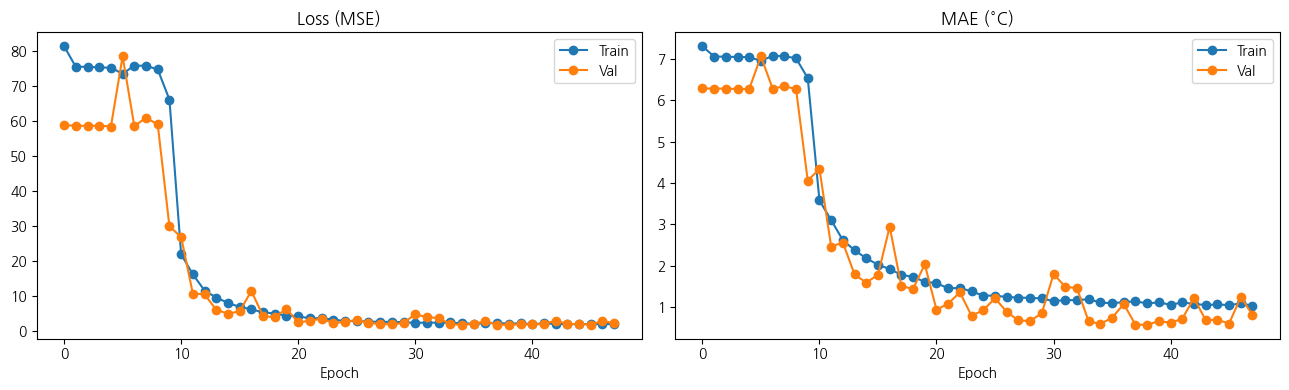

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(history_jena.history['loss'],     marker='o', label='Train')
axes[0].plot(history_jena.history['val_loss'], marker='o', label='Val')
axes[0].set_title('Loss (MSE)'); axes[0].set_xlabel('Epoch'); axes[0].legend()

axes[1].plot(history_jena.history['mae'],     marker='o', label='Train')
axes[1].plot(history_jena.history['val_mae'], marker='o', label='Val')
axes[1].set_title('MAE (°C)'); axes[1].set_xlabel('Epoch'); axes[1].legend()

plt.tight_layout(); plt.show()

27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step


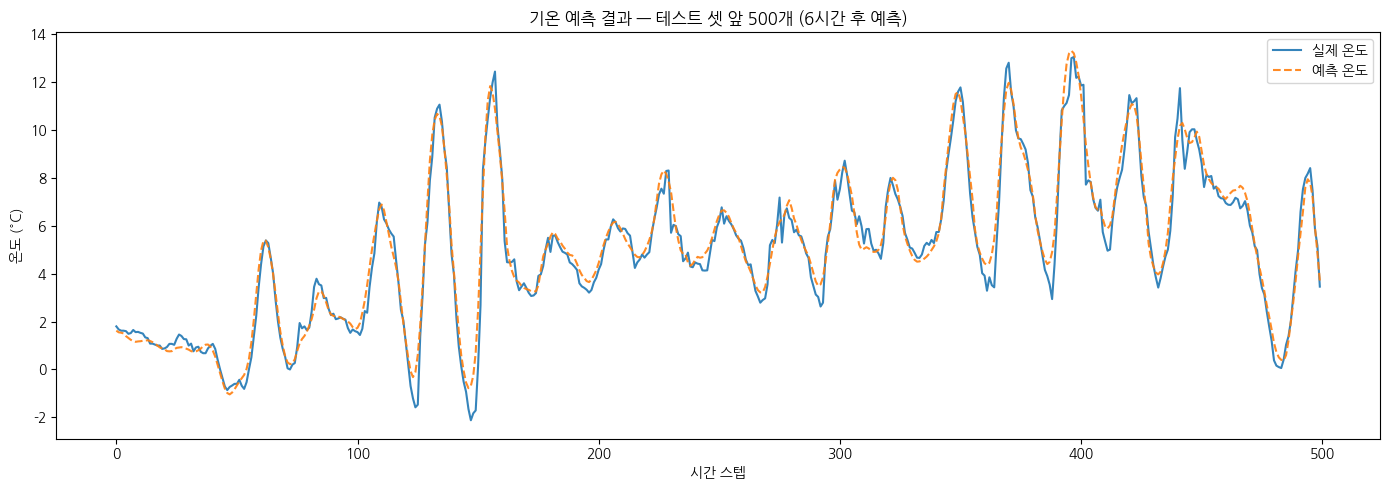

🎯 테스트 MSE: 0.4177  |  테스트 MAE: 0.4682 °C
   → 평균 0.47°C 오차로 예측!


In [42]:
# ── 테스트 셋 예측 & 시각화 ─────────────────────────────────────
y_pred   = model_jena.predict(test_tf).flatten()
y_actual = np.concatenate([y for _, y in test_tf])

plt.figure(figsize=(14, 5))
plt.plot(y_actual[:500], label='실제 온도', alpha=0.9)
plt.plot(y_pred[:500],   label='예측 온도', linestyle='--', alpha=0.9)
plt.title('기온 예측 결과 — 테스트 셋 앞 500개 (6시간 후 예측)')
plt.ylabel('온도 (°C)'); plt.xlabel('시간 스텝')
plt.legend(); plt.tight_layout(); plt.show()

test_loss, test_mae = model_jena.evaluate(test_tf, verbose=0)
print(f"🎯 테스트 MSE: {test_loss:.4f}  |  테스트 MAE: {test_mae:.4f} °C")
print(f"   → 평균 {test_mae:.2f}°C 오차로 예측!")

---

# 🔤 PART 5. Character-Level Seq2Seq — 소문자 → 대문자 변환

**Seq2Seq** (Sequence-to-Sequence) 는 입력 시퀀스를 받아 다른 시퀀스를 출력하는 구조입니다.
기계 번역, 텍스트 요약, 챗봇 등에 활용됩니다.

## 🔑 핵심 구조

```
"hello"
   ↓
[인코더 LSTM] → hidden state (h, c) = "컨텍스트 벡터"
                                ↓
                     [디코더 LSTM] → "H"
                                   → "E"
                                   → "L"
                                   → "L"
                                   → "O"
```

### 인코더 (Encoder)
입력 시퀀스를 **왼쪽→오른쪽으로 읽으며** 마지막 `(h, c)` = **컨텍스트 벡터**에 전체 문맥을 압축합니다.

### 디코더 (Decoder)
컨텍스트 벡터를 초기 상태로 받아, **한 글자씩 순차적으로 생성**합니다.
`<start>` 토큰(`	`)을 첫 입력으로 주면, 이후 `<end>` 토큰(`
`)이 나올 때까지 생성합니다.

### Teacher Forcing 💡
학습 시 디코더의 각 스텝에 **이전 예측값 대신 실제 정답**을 입력으로 넣습니다.
- 왜? 초기 예측이 틀리면 오류가 쌓여 학습이 불안정해질 수 있기 때문
- `decoder_input_data`  : `	` + 정답 (시작 토큰 붙인 정답)
- `decoder_target_data` : 정답 + `
` (끝 토큰 붙인 정답)

### 학습 vs 추론 모델 분리

| | 학습 모델 | 추론 모델 |
|:---:|:---:|:---:|
| 디코더 입력 | 실제 정답 (Teacher Forcing) | 이전 예측값 |
| 사용 시점 | 학습 시 | 실제 예측 시 |

---

## 5-1. 학습 데이터 준비

`words.txt` 파일을 로드합니다

In [44]:
# ── words.txt에서 데이터 로드 ──────────────────────────────────
# 로드가 안된다면 파일을 구글 드라이브에 안올렸거나, 드라이브 연결이 잘 안된거니 확인해주세요!
# 1. 원본 데이터: 20000개의 NLTK 랜덤 영단어
# (예시 입력: "hello", 예시 타겟: "\tHELLO\n")
# \t: 시작 토큰(Start of Sequence)
# \n: 종료 토큰(End of Sequence)

file_path = '/content/words.txt'
raw_data = []

try:
    with open(file_path, 'r', encoding='utf-8') as f:
        for line in f:
            # 줄바꿈 문자 제거 후, 쉼표(,)를 기준으로 나눔
            parts = line.strip().split(',')
            # 데이터가 정상적으로 2개(소문자, 대문자)인 경우만 추가
            if len(parts) == 2:
                raw_data.append((parts[0], parts[1]))

    print(f"파일에서 {len(raw_data)}개의 단어를 성공적으로 불러왔습니다!")
    # 확인용 출력
    print(raw_data[:5])

except FileNotFoundError:
    print(f"오류: '{file_path}' 파일을 찾을 수 없습니다.")

파일에서 20000개의 단어를 성공적으로 불러왔습니다!
[('deadlily', 'DEADLILY'), ('liparis', 'LIPARIS'), ('sairly', 'SAIRLY'), ('forenamed', 'FORENAMED'), ('tilework', 'TILEWORK')]


In [45]:
# 2. 문자 사전(Vocabulary) 구축
input_chars = set()
target_chars = set()

for input_text, target_text in raw_data:
    target_text = "\t" + target_text + "\n" # 타겟에 시작 문자(\t)/종료 문자(\n) 추가
    for char in input_text:
        input_chars.add(char)
    for char in target_text:
        target_chars.add(char)

input_chars = sorted(list(input_chars))
target_chars = sorted(list(target_chars))
num_encoder_tokens = len(input_chars)
num_decoder_tokens = len(target_chars)

In [46]:
# 3. 문자 <-> 인덱스 매핑 (Dictionary)
input_token_index = dict([(char, i) for i, char in enumerate(input_chars)])
target_token_index = dict([(char, i) for i, char in enumerate(target_chars)])

print(f"입력 문자 사전 (크기: {num_encoder_tokens}): {input_chars}")
print(f"타겟 문자 사전 (크기: {num_decoder_tokens}): {target_chars}")

입력 문자 사전 (크기: 26): ['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']
타겟 문자 사전 (크기: 28): ['\t', '\n', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z']


In [47]:
# 4. 시퀀스 길이 계산
max_encoder_seq_length = max([len(txt) for txt, _ in raw_data])
max_decoder_seq_length = max([len(txt) + 2 for _, txt in raw_data]) # \t(시작 신호 문자), \n(종료 신호 문자) 포함

In [48]:
# 5. 데이터 벡터화 (One-Hot Encoding)
# Keras 모델에 입력할 3D Numpy 배열 (samples, timesteps, features)
# features = 사전 크기 (One-hot)

encoder_input_data = np.zeros(
    (len(raw_data), max_encoder_seq_length, num_encoder_tokens), dtype="float32"
)
decoder_input_data = np.zeros(
    (len(raw_data), max_decoder_seq_length, num_decoder_tokens), dtype="float32"
)
decoder_target_data = np.zeros(
    (len(raw_data), max_decoder_seq_length, num_decoder_tokens), dtype="float32"
)

In [49]:
# 6. 데이터 채우기
for i, (input_text, target_text) in enumerate(raw_data):
    target_text = "\t" + target_text + "\n"

    # 6-1. 인코더 입력 데이터
    for t, char in enumerate(input_text):
        encoder_input_data[i, t, input_token_index[char]] = 1.0

    # 6-2. 디코더 입력/타겟 데이터 (Teacher Forcing)
    for t, char in enumerate(target_text):
        # 디코더 입력: "\tHELLO"
        decoder_input_data[i, t, target_token_index[char]] = 1.0

        # 디코더 타겟: "HELLO\n" (입력보다 1스텝 밀림)
        if t > 0:
            decoder_target_data[i, t - 1, target_token_index[char]] = 1.0

In [50]:
print("--- 데이터 벡터화 (예시: 'hello' -> '\tHELLO\n') ---")
print(f"encoder_input_data shape: {encoder_input_data.shape}")
print(f"decoder_input_data shape: {decoder_input_data.shape}")
print(f"decoder_target_data shape: {decoder_target_data.shape}")

--- 데이터 벡터화 (예시: 'hello' -> '	HELLO
') ---
encoder_input_data shape: (20000, 10, 26)
decoder_input_data shape: (20000, 12, 28)
decoder_target_data shape: (20000, 12, 28)


모델 구축(LSTM Encoder/Decoder) 및 추론(Inference) 모델 분리 과정

- 바로 밑에 부터 학습 모델과 추론 모델을 분리하기 시작합니다!!!

In [51]:
# latent_dim: 인코더가 입력 문장의 정보를 압축하여 저장하는 벡터 공간의 크기, 일반적으로 128, 256, 512 등의 값을 사용합니다
# 너무 크면 과적합이 발생할 수 있고, 너무 작으면 문장의 정보를 충분히 담지 못해 성능 저하가 생길 수 있습니다.

# 이번에는 256으로 설정해 봅시다.
latent_dim = 256

# 이 모델은 'Teacher Forcing'을 사용하여 학습합니다.
# 우리가 만든 encoder_input_data, decoder_input_data, decoder_target_data 3종류를 사용합니다.

### **decoder_input_data와 decoder_target_data를 왜 분리할까요??**

💡 학습의 핵심: "Teacher Forcing"

모델을 '학습'시킬 때, 위의 d 단계에서 "자신이 예측한 값"을 다시 입력으로 넣는 학습을 시킨다고 생각해 봅시다.  
이 때는 초반에 모델이 엉뚱한 값을 예측했다면, 그 이후의 학습이 매우 불안정해집니다. (엉뚱한 입력을 받고 계속 엉뚱한 예측을 하게 됨)

> 그래서 우리는 **학습 시에 "정답"을 강제로 알려주며 훈련시킵니다. 이것이 Teacher Forcing입니다.**

> 그리고
이것이 바로 코드에서 decoder_input_data와 decoder_target_data를 분리하는 이유입니다.

"hello" ➔ "HELLO" 예시:

Encoder Input: h, e, l, l, o ➡️ (인코더가 읽고 컨텍스트 벡터 생성)

Decoder Input (Teacher Forcing용): \t, H, E, L, L, O (시작 토큰 \t으로 시작) ➡️ (디코더는 이 '정답' 입력을 한 글자씩 받으면서 학습)

Decoder Target (실제 정답): H, E, L, L, O, \n (1 스텝씩 밀려남) ➡️ (모델은 \t를 보고 H를, H를 보고 E를... 예측하도록 학습됨)

> 이러한 구조 때문에, Seq2Seq 모델은 **학습용 모델**과 (나중에 결과를 볼 때 사용하는) **추론용(Inference) 모델**을 따로 정의해야 합니다.

In [53]:
## 1. 인코더(Encoder) 정의
# (samples, max_encoder_seq_length, num_encoder_tokens) 크기의 입력을 받음

# 인코더 입력 정의
# Keras 모델의 시작점인 Input 레이어를 사용하세요.
encoder_inputs = keras.Input(shape=(None, num_encoder_tokens))

# 인코더 LSTM 정의
# 시퀀스 데이터를 처리하기 위한 LSTM 레이어를 사용하세요.
# 디코더에 초기 상태를 전달하기 위해 return_state=True로 설정해야 합니다.
encoder_lstm = layers.LSTM(latent_dim, return_state=True)

# encoder_outputs는 사용하지 않지만, 'state_h'와 'state_c' (컨텍스트 벡터)를 얻음
# LSTM 레이어는 출력(outputs), 은닉 상태(state_h), 셀 상태(state_c)를 반환합니다.
encoder_outputs, state_h, state_c = encoder_lstm(encoder_inputs)

# 'state_h'와 'state_c'를 묶어서 'encoder_states'라고 부름
# 이 상태들이 디코더의 초기 상태로 사용되어 인코더의 정보를 전달합니다.
encoder_states = [state_h, state_c] # 이것이 '컨텍스트 벡터'입니다.

In [54]:
## 2. 디코더(Decoder) 정의
# (samples, max_decoder_seq_length, num_decoder_tokens) 크기의 입력을 받음

# 디코더 입력 정의
decoder_inputs = keras.Input(shape=(None, num_decoder_tokens))

# 디코더 LSTM 정의
# return_sequences=True로 설정하여 모든 타임스텝의 출력을 반환받습니다.
# return_state=True로 설정하여 디코더의 상태도 반환받습니다(추론 시 필요).
decoder_lstm = layers.LSTM(latent_dim, return_sequences=True, return_state=True)


# ☆ 디코더는 'encoder_states'를 초기 상태(initial_state)로 받습니다.☆
# 이것이 인코더와 디코더를 연결하는 고리입니다.
# 인코더가 생성한 컨텍스트 벡터를 디코더의 시작점으로 사용하여 번역 등을 수행합니다.
decoder_outputs, _, _ = decoder_lstm(decoder_inputs, initial_state=encoder_states)

In [55]:
# 3. 디코더 출력층 (Dense)
# 디코더의 각 타임스텝 출력(latent_dim)을 타겟 문자 사전 크기(num_decoder_tokens)로 변환
decoder_dense = layers.Dense(num_decoder_tokens, activation="softmax")
decoder_outputs = decoder_dense(decoder_outputs)

In [56]:
## 4. 최종 '학습용' 모델 정의
# inputs: [인코더 입력, 디코더 입력]
# outputs: [디코더 타겟]
model = keras.Model([encoder_inputs, decoder_inputs], decoder_outputs)

In [57]:
# 5. 모델 컴파일 및 학습
model.compile(
    optimizer="rmsprop", loss="categorical_crossentropy", metrics=["accuracy"]
)
# 이번에는 RMSProp 옵티마이저

print("--- 학습용 모델(Training Model) 요약 ---")
model.summary()

--- 학습용 모델(Training Model) 요약 ---


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, None, 26)  │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_5       │ (None, None, 28)  │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_10 (LSTM)      │ [(None, 256),     │    289,792 │ input_layer_4[0]… │
│                     │ (None, 256),      │            │                   │
│                     │ (None, 256)]      │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_11 (LSTM)      │ [(None, None,     │    291,840 │ input_layer_5[0]… │
│                     │ 256), (None,      │            │ lstm_10[0][1],    │
│                     │ 256), (None,      │            │ lstm_10[0][2]     │
│                     │ 256)]             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, None, 28)  │      7,196 │ lstm_11[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 588,828 (2.25 MB)

 Trainable params: 588,828 (2.25 MB)

 Non-trainable params: 0 (0.00 B)

In [60]:
from tensorflow.keras.callbacks import EarlyStopping

# EarlyStopping 객체 설정
early_stopping_callback = EarlyStopping(monitor='val_loss', # 힌트: EarlyStopping에서 어떤 점수를 보면서 감시할지 정하는 파라미터는? monitor
                                        patience=20,
                                        restore_best_weights=True)

# 모델 학습
model.fit(
     [encoder_input_data, decoder_input_data], # 2개의 입력[인코더 인풋, 디코더 인풋]
     decoder_target_data,                      # 1개의 출력[디코더 타겟]
     batch_size=128,
     epochs=100,  # epoch를 늘리고, EarlyStopping을 씁니다.
     validation_split=0.2, # 전체 학습 데이터의 20%를 자동으로 분리하여 검증 셋의 용도로 사용합니다.
     callbacks=[early_stopping_callback]
    )

Epoch 1/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 7s 24ms/step - accuracy: 0.1305 - loss: 2.1234 - val_accuracy: 0.1729 - val_loss: 2.0146
Epoch 2/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.1937 - loss: 1.9173 - val_accuracy: 0.2024 - val_loss: 1.8481
Epoch 3/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.2343 - loss: 1.7147 - val_accuracy: 0.2477 - val_loss: 1.6745
Epoch 4/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.2780 - loss: 1.5554 - val_accuracy: 0.3239 - val_loss: 1.4254
Epoch 5/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.3280 - loss: 1.4130 - val_accuracy: 0.3741 - val_loss: 1.2997
Epoch 6/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.3793 - loss: 1.2724 - val_accuracy: 0.3530 - val_loss: 1.3442
Epoch 7/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.4269 - loss: 1.1380 - val_accuracy: 0.4540 - val_loss: 1.0931
Epoch 8/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.4667 - loss: 1.0227 - val_ac

In [61]:
## 1. 인코더 모델 (Inference)
# 기능: 입력 문장 -> 컨텍스트 벡터 [state_h, state_c]
encoder_model = keras.Model(encoder_inputs, encoder_states)

In [62]:
## 2. 디코더 모델 (Inference)
# 디코더는 2가지 입력을 받아야 함:
# (a) 인코더에서 받은 컨텍스트 벡터 (상태)
# (b) 이전 타임스텝에서 예측한 문자 1개
decoder_state_input_h = keras.Input(shape=(latent_dim,))
decoder_state_input_c = keras.Input(shape=(latent_dim,))
decoder_states_inputs = [decoder_state_input_h, decoder_state_input_c]

# (decoder_inputs는 이전 단계의 Keras.Input(shape=(None, num_decoder_tokens)) 입니다)
# 학습 때 사용했던 'decoder_lstm' 레이어를 그대로 사용
decoder_outputs, state_h, state_c = decoder_lstm(
    decoder_inputs, initial_state=decoder_states_inputs
)
decoder_states = [state_h, state_c] # 갱신된 상태 (다음 루프에 사용)

# (학습 때 사용했던 'decoder_dense' 레이어를 그대로 사용)
decoder_outputs = decoder_dense(decoder_outputs)

# 최종 '디코더 추론용' 모델
# inputs: [이전 예측 문자 1개, 이전 상태 h, 이전 상태 c]
# outputs: [다음 문자 예측(softmax), 갱신된 상태 h, 갱신된 상태 c]
decoder_model = keras.Model(
    [decoder_inputs] + decoder_states_inputs, [decoder_outputs] + decoder_states
)

In [63]:
print("--- 추론용 인코더 모델(Inference Encoder) 요약 ---")
encoder_model.summary()
print("\n--- 추론용 디코더 모델(Inference Decoder) 요약 ---")
decoder_model.summary()

--- 추론용 인코더 모델(Inference Encoder) 요약 ---


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, None, 26)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_10 (LSTM)                  │ [(None, 256), (None,   │       289,792 │
│                                 │ 256), (None, 256)]     │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 289,792 (1.11 MB)

 Trainable params: 289,792 (1.11 MB)

...

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5       │ (None, None, 28)  │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_6       │ (None, 256)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_7       │ (None, 256)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_11 (LSTM)      │ [(None, None,     │    291,840 │ input_layer_5[0]… │
│                     │ 256), (None,      │            │ input_layer_6[0]… │
│                     │ 256), (None,      │            │ input_layer_7[0]… │
│                     │ 256)]             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, None, 28)  │      7,196 │ lstm_11[1][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 299,036 (1.14 MB)

 Trainable params: 299,036 (1.14 MB)

 Non-trainable params: 0 (0.00 B)

In [64]:
# 1. 인덱스 -> 문자 변환 딕셔너리 (결과 확인용)
reverse_input_char_index = dict((i, char) for char, i in input_token_index.items())
reverse_target_char_index = dict((i, char) for char, i in target_token_index.items())

In [65]:
# 2. 예측(번역)을 수행하는 'decode_sequence' 함수 정의
def decode_sequence(input_text):
    # (a) 입력 문장을 원-핫(one-hot) 벡터로 변환
    input_seq = np.zeros(
        (1, max_encoder_seq_length, num_encoder_tokens), dtype="float32"
    )
    for t, char in enumerate(input_text):
        if char in input_token_index:
            input_seq[0, t, input_token_index[char]] = 1.0

    # (b) 'encoder_model'로 입력 문장의 컨텍스트 벡터(states) 추출
    states_value = encoder_model.predict(input_seq)

    # (c) 디코더의 첫 입력: '\t' (시작 토큰)
    target_seq = np.zeros((1, 1, num_decoder_tokens), dtype="float32")
    target_seq[0, 0, target_token_index["\t"]] = 1.0

    stop_condition = False
    decoded_sentence = ""

    # (d) 루프 시작: 한 글자씩 예측
    while not stop_condition:
        # 'decoder_model'로 다음 문자 예측
        # 입력: (이전 문자, 이전 states_value)
        # 출력: (예측 문자, 새로운 states_value_h, 새로운 states_value_c)
        output_tokens, h, c = decoder_model.predict([target_seq] + states_value)

        # 예측된 문자의 인덱스 찾기 (가장 확률이 높은 것)
        sampled_token_index = np.argmax(output_tokens[0, -1, :])
        # 인덱스를 문자로 변환
        sampled_char = reverse_target_char_index[sampled_token_index]

        # 예측된 문자를 결과 문장에 추가
        decoded_sentence += sampled_char

        # (e) 종료 조건 확인
        # '\n' (종료 토큰)이 예측되거나 최대 길이를 초과하면 중지
        if sampled_char == "\n" or len(decoded_sentence) > max_decoder_seq_length:
            stop_condition = True

        # (f) 다음 루프를 위해 입력 업데이트
        # target_seq: 다음 입력으로 방금 예측한 문자를 사용
        target_seq = np.zeros((1, 1, num_decoder_tokens), dtype="float32")
        target_seq[0, 0, sampled_token_index] = 1.0
        # states_value: 다음 입력으로 방금 받은 새로운 state를 사용
        states_value = [h, c]

    return decoded_sentence

In [66]:
# 3. 앞 10개 단어로 테스트 실행
print("--- Seq2Seq 소문자 ➡️ 대문자 번역 테스트 ---")
for data in raw_data[:10]:
    input_text = data[0]
    decoded_text = decode_sequence(input_text)
    print(f"입력: '{input_text}'")
    print(f"예측: '{decoded_text.strip()}'") # .strip()으로 \n 제거

--- Seq2Seq 소문자 ➡️ 대문자 번역 테스트 ---
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 667ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
입력: 'deadlily'
예측: 'DEADLIL'
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
입력: 'liparis'
예측: 'LIPARI'
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/s

In [67]:
# 뒤 10개 단어로 테스트 실행
print("--- Seq2Seq 소문자 ➡️ 대문자 번역 테스트 ---")
for data in raw_data[-10:]:
    input_text = data[0]
    decoded_text = decode_sequence(input_text)
    print(f"입력: '{input_text}'")
    print(f"예측: '{decoded_text.strip()}'") # .strip()으로 \n 제거

--- Seq2Seq 소문자 ➡️ 대문자 번역 테스트 ---
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
입력: 'toxosozin'
예측: 'TOXOOSIN'
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
입력: 'echeveria'
예측: 'ECHEVERIA'
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 4

In [68]:
# 새로운 단어로 테스트해봅시다. 아래 리스트에 원하는 단어들을 넣어볼까요?
# 저는 ['python', 'keras', 'insight', 'thanks']를 넣었습니다.
new_data = ['home', 'study', 'job']

for new_word in new_data:
    input_text = new_word
    decoded_text = decode_sequence(input_text)
    print(f"입력: '{input_text}'")
    print(f"예측: '{decoded_text.strip()}'")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
입력: 'home'
예측: 'HOME'
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
입력: 'study'
예측: 'STUD'
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
입력: 'job'
예측: 'JO'


---

## 🎓 전체 정리
#### 실습에서 한 CNN/RNN/LSTM/GRU 중 CNN(part1,2)과 LSTM(part3,4,5)를 중점으로 학습했습니다!

### PART 1 — Cats vs Dogs (이진 분류, PyTorch)
- CNN 직접 구현 : Conv+BN+ReLU+Pool 블록 3개 + AdaptiveAvgPool + FC
- **albumentations** 증강 : Flip, Rotate, ColorJitter
- **BCEWithLogitsLoss** + Sigmoid → 0.5 임계값으로 이진 판단
- **Early Stopping** 으로 과적합 방지, Best 모델 저장

### PART 2 — CIFAR-10 (다중 분류, 전이학습, PyTorch)
- **ResNet18 전이학습** : layer4 + fc만 재학습 (전체의 ~10%만 학습)
- **CrossEntropyLoss** + AdamW + **StepLR 스케줄러**
- **Confusion Matrix** 로 클래스 간 혼동 패턴 분석

### PART 3 — IMDB 감성 분석 (Bidirectional LSTM, Keras)
- **Embedding** → 단어를 128차원 의미 벡터로 변환
- **Bidirectional LSTM** → 앞뒤 문맥 동시 파악
- Padding으로 가변 길이 시퀀스를 배치 처리

### PART 4 — 예나 기온 예측 (다변량 LSTM, Keras)
- 14개 피처 → 6시간 뒤 기온 예측 (회귀)
- **시간 순서 분할** + 훈련 통계로만 정규화 (데이터 누수 방지)
- Keras `timeseries_dataset_from_array` 슬라이딩 윈도우
- **Stacked LSTM** (2층) + EarlyStopping

### PART 5 — Seq2Seq 소문자 → 대문자 (Keras)
- **인코더** : 입력 → 컨텍스트 벡터 (h, c)
- **Teacher Forcing** : 학습 안정화
- **학습 모델 ↔ 추론 모델 분리** : 추론 시 자기회귀 생성

---

## 🎉 수고하셨습니다!